In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd

# Your refactored code (adjust module name if needed)
from neural_encoding import regression as reg
from neural_encoding import reliability as rel
from neural_encoding import spike_processing as spu

from typing import Any, Dict, List, cast



# =========================
# CONFIG (EDIT ME)
# =========================
patient_cfg = {
    "patient_ID": "PTYEZ_task60",
    "prefix": "ptYEZ_task60",
    "n_components": 10,
    "region_ranges": {
        "hippocampus": [(1,16)],
        "ACC": [(17,24)],
    }
}

ROOT_SPIKES = "/projects/bhayden/anilu/Language_docs/Regression/SpikesMAT"

def get_paths_local(patient_ID, prefix):
    short_id = patient_ID[2:5]  # e.g. "YEZ"
    base_dir = f"/projects/bhayden/anilu/Language_docs/Regression/{patient_ID}_words_english_only"
    return {
        "mat": os.path.join(ROOT_SPIKES, short_id, f"{prefix}_new_spikes.mat"),
        "embedding_csv": f"{base_dir}/{patient_ID}_aligned_embeddings_withNP.csv",
        "base_excel": f"{base_dir}/{patient_ID}_filtered_used_rows_withNP.xlsx",
    }

paths = get_paths_local(patient_cfg["patient_ID"], patient_cfg["prefix"])
regions = list(patient_cfg["region_ranges"].keys())

# One fixed-window config (edit shifts/lengths)
window_cfg = {
    "name": "tshift-220_tlen500_oshift+410_olen500",
    "mode": "target_vs_other_fixed_window_from_ref",
    "speaker_of_interest": "Speaker1",
    "target_ref_point": "onset",
    "target_shift": -150,
    "target_window_length": 500,
    "other_ref_point": "onset",
    "other_shift": 200,
    "other_window_length": 500,
}

# Duration setup:
#   duration_choice: "none" | "word_dur" | "regress_dur"
#   duration_mode:   "none" | "covariate" | "offset"
duration_choice = "none"          # <- change to "word_dur" or "regress_dur"
duration_mode = "none"            # <- if duration_choice != "none": "covariate" or "offset"
include_interactions = True       # only used if duration_mode == "covariate"
agg = "sum"                       # spike aggregation over window: "sum" typically

target_speaker = "SPK1"


# =========================
# 1) Extract spike windows (speaker_events)
# =========================
speaker_events = spu.extract_speaker_events(
    paths["base_excel"],
    mode=window_cfg["mode"],
    speaker_of_interest=window_cfg["speaker_of_interest"],
    target_ref_point=window_cfg["target_ref_point"],
    target_shift=int(window_cfg["target_shift"]),
    target_window_length=int(window_cfg["target_window_length"]),
    other_ref_point=window_cfg["other_ref_point"],
    other_shift=int(window_cfg["other_shift"]),
    other_window_length=int(window_cfg["other_window_length"]),
)

# Optional sanity: confirm window durations
for k, ev in list(speaker_events.items())[:3]:
    if len(ev) == 0:
        continue
    print("Speaker key:", k, "unique window durs:", np.unique(ev[:, 3])[:10])


# =========================
# 2) Build a duration table with BOTH word_dur and regress_dur
#    - word_dur: onset->offset
#    - regress_dur: window length from speaker_events (post_offset-pre_onset)
# =========================
df_xl = pd.read_excel(paths["base_excel"], sheet_name="Sheet1", keep_default_na=False)
df_xl = spu.add_regress_dur_column(df_xl, speaker_events=speaker_events, add_bounds_cols=True)

duration_tmp = os.path.join(os.path.dirname(paths["base_excel"]), f"_tmp_durations_{window_cfg['name']}.xlsx")
df_xl.to_excel(duration_tmp, index=False)
print("Saved duration table:", duration_tmp)


# =========================
# 3) Build X_self / X_other (embeddings -> PCA -> +duration/+interactions)
# =========================
if duration_choice == "none":
    fcfg = reg.FeatureConfig(
        n_pcs=patient_cfg["n_components"],
        duration_mode="none",
        include_interactions=False,
        pca_fit="all",
        standardize=True,
    )
    duration_col = "word_dur"  # unused
else:
    if duration_choice == "word_dur":
        duration_col = "word_dur"
    elif duration_choice == "regress_dur":
        duration_col = "regress_dur"
    else:
        raise ValueError("duration_choice must be none|word_dur|regress_dur")

    fcfg = reg.FeatureConfig(
        n_pcs=patient_cfg["n_components"],
        duration_mode=duration_mode,  # "covariate" or "offset"
        include_interactions=(include_interactions and duration_mode == "covariate"),
        interaction_uses="duration",
        pca_fit="all",
        standardize=True,
    )

X_self, X_other, off_s, off_o, df_meta = reg.build_self_other_design(
    embedding_csv_path=paths["embedding_csv"],
    duration_path=duration_tmp,
    fcfg=fcfg,
    target_speaker=target_speaker,
    duration_col=duration_col,
)

print("X built:")
print("  X_self:", X_self.shape)
print("  X_other:", X_other.shape)

if duration_mode == "offset":
    assert off_s is not None and off_o is not None
    print("  offsets (self/other):", off_s.shape, off_o.shape)


# =========================
# 4) Build Y_self / Y_other per region from raw spikes + speaker_events
# =========================
spikes, qual, chan = spu.load_mat_data(paths["mat"])
region_cells = spu.get_cells_by_region(chan, qual, patient_cfg["region_ranges"])

ycfg = reg.YBuildConfig(target_speaker=target_speaker, speaker_key_style="SpeakerN")
region_Ys = reg.build_region_Y_from_raw_spikes_and_events(
    metadata=df_meta,
    spikes=spikes,
    region_cells=region_cells,
    speaker_events=speaker_events,
    regions=regions,
    cfg=ycfg,
    agg=agg,
)


# =========================
# 5) Align X (and offsets) to Y indices
#    This is what guarantees X and Y row counts match.
# =========================
idx_self_global = df_meta.index[df_meta["Speaker"].astype(str) == target_speaker].to_numpy()
idx_other_global = df_meta.index[df_meta["Speaker"].astype(str) != target_speaker].to_numpy()

pos_self = {int(ix): j for j, ix in enumerate(idx_self_global)}
pos_other = {int(ix): j for j, ix in enumerate(idx_other_global)}

XY = {}

for region in regions:
    ry = region_Ys.get(region)
    if ry is None:
        print(f"[{region}] missing Y output")
        continue

    used_self = [pos_self[i] for i in ry["indices_self"] if i in pos_self]
    used_other = [pos_other[i] for i in ry["indices_other"] if i in pos_other]

    Xs = X_self[used_self, :]
    Xo = X_other[used_other, :]
    Ys = ry["self"]
    Yo = ry["other"]

    if Xs.shape[0] != Ys.shape[0]:
        raise RuntimeError(f"[{region}] self mismatch: X{Xs.shape} vs Y{Ys.shape}")
    if Xo.shape[0] != Yo.shape[0]:
        raise RuntimeError(f"[{region}] other mismatch: X{Xo.shape} vs Y{Yo.shape}")

    # Align offsets too (only if offset mode)

    off_self_aligned = None
    off_other_aligned = None

    if duration_mode == "offset":
        # Tell Pylance (and future-you) these are guaranteed in offset mode
        assert off_s is not None and off_o is not None

        off_self_aligned = off_s[used_self]
        off_other_aligned = off_o[used_other]

    XY[region] = dict(
        X_self=Xs, Y_self=Ys,
        X_other=Xo, Y_other=Yo,
        offset_self=off_self_aligned,
        offset_other=off_other_aligned,
        meta=df_meta,
    )

    print(f"\n[{region}] FINAL")
    print("  X_self:", Xs.shape, "Y_self:", Ys.shape)
    print("  X_other:", Xo.shape, "Y_other:", Yo.shape)

    if duration_mode == "offset":
        # aligned offsets must exist here too
        assert off_self_aligned is not None and off_other_aligned is not None
        print("  offset_self:", off_self_aligned.shape, "offset_other:", off_other_aligned.shape)


print("\nDONE. XY regions:", list(XY.keys()))



✅ Word counts after extraction:
Speaker2: 3180
Speaker1: 2068
Speaker3: 31
Speaker key: Speaker2 unique window durs: [500.]
Speaker key: Speaker1 unique window durs: [500.]
Speaker key: Speaker3 unique window durs: [500.]
Saved duration table: /projects/bhayden/anilu/Language_docs/Regression/PTYEZ_task60_words_english_only/_tmp_durations_tshift-220_tlen500_oshift+410_olen500.xlsx
X built:
  X_self: (2068, 10)
  X_other: (3211, 10)

[hippocampus] FINAL
  X_self: (2068, 10) Y_self: (2068, 28)
  X_other: (3211, 10) Y_other: (3211, 28)

[ACC] FINAL
  X_self: (2068, 10) Y_self: (2068, 12)
  X_other: (3211, 10) Y_other: (3211, 12)

DONE. XY regions: ['hippocampus', 'ACC']


# Actual runner

In [12]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd

# Your refactored code (adjust module name if needed)
from neural_encoding import regression as reg
from neural_encoding import reliability as rel
from neural_encoding import spike_processing as spu

from typing import Any, Dict, List, cast
import numpy as np
import pandas as pd
from joblib import Parallel, delayed


# =========================
# CONFIG (EDIT ME)
# =========================
PATIENTS = [
    {
        "patient_ID": "PTYFF_task17",
        "prefix": "ptYFF_task17",
        "region_ranges": {
             "hippocampus": [(9,16),(25,40)],
                "ACC": [(17,24),(41,48)]
        }
    },
    {
        "patient_ID": "PTYEU_task147",
        "prefix": "ptYEU_task147",
        "region_ranges": {
            "hippocampus": [(1, 16), (25, 40)],
            "ACC": [(17, 24), (41, 48)]
        }
    },
    {
        "patient_ID": "PTYFC_task28",
        "prefix": "ptYFC_task28",
        "region_ranges": {
            "hippocampus": [(1,8),(33,48)],
                "ACC": [(17,32),(49,64)]
        }
    },
        {
        "patient_ID": "PTYEV_task37",
        "prefix": "ptYEV_task37",
        "region_ranges": {
             "hippocampus": [(1,16),(25,40)],
                "ACC": [(17,24),(41,48)]
        }
    },
        {
        "patient_ID": "PTYEZ_task60",
        "prefix": "ptYEZ_task60",
        "region_ranges": {
             "hippocampus": [(1,16)],
                "ACC": [(17,24)]
        }
    },
        {
        "patient_ID": "PTYFG_task18",
        "prefix": "ptYFG_task18",
        "region_ranges": {
            "hippocampus": [(9,16)],
             "ACC": [(25,56)]
        }
    },
    {
        "patient_ID": "PTYFK_task40",
        "prefix": "ptYFK_task40",
        "region_ranges": {
            "hippocampus": [(1,16),(25,40)],
                "ACC": [(49,56)],
        }
    },
           {
        "patient_ID": "PTYFI_task81",
        "prefix": "ptYFI_task81",
        "region_ranges": {
               "hippocampus": [(1,8),(25,40)],
                "ACC": [(9,16)]
        }
    },
            {
        "patient_ID": "PTYFA_task25",
        "prefix": "ptYFA_task25",
        "region_ranges": {
            "hippocampus": [(1,16),(25,40)],
                "ACC": [(17,24)],
        }
    },
    {
        "patient_ID": "PTYEY_task86",
        "prefix": "ptYEY_task86",
        "region_ranges": {
              "hippocampus": [(1,16)],
             
        }
    },
]

BALANCE_OTHER_TO_SELF = True
BALANCE_MAX_RATIO = 1.5    # other trials <= ratio * self trials

USE_SHARED_ALPHA = True     # if False → separate alphas (current behavior)

ALPHA_CFG = reg.AlphaConfig(
    alphas=np.logspace(-6, 3, 40),
    inner_cv=reg.SplitConfig(
        method="contiguous_kfold",
        n_splits=5,
        shuffle=False,
        random_state=0
    )
)

REGIONS = ["hippocampus"]  # or ["hippocampus","ACC"]

ROOT_SPIKES = "/projects/bhayden/anilu/Language_docs/Regression/SpikesMAT"
RESULTS_ROOT = "/projects/bhayden/anilu/Language_docs/PC_SWEEPS_BETA_REL_MAINPIPELINE"

PC_LIST = [50]
N_NULL = 500
N_HALF_SPLITS = 500
N_JOBS = 12
BACKEND = "torch"

WINDOW_CFG = {
    "name": "tshift-150_tlen500_oshift+200_olen500",
    "mode": "target_vs_other_fixed_window_from_ref",
    "speaker_of_interest": "Speaker1",
    "target_ref_point": "onset",
    "target_shift": -150,
    "target_window_length": 500,
    "other_ref_point": "onset",
    "other_shift": 200,
    "other_window_length": 500,
}

# Duration in X?
DURATION_CHOICE = "none"        # "none" | "word_dur" | "regress_dur"
INCLUDE_INTERACTIONS = False    # only relevant if DURATION_CHOICE != "none"

# Alpha selection: contiguous is better for sequential word streams
ALPHA_CFG = reg.AlphaConfig(
    alphas=np.logspace(-3, 3, 30),
    inner_cv=reg.SplitConfig(
        method="contiguous_kfold",
        n_splits=5,
        shuffle=False,
        random_state=0   # harmless even if shuffle=False
    )
)

# Null shuffle: choose based on whether duration is included
if DURATION_CHOICE == "none":
    X_SHUFFLE_MODE = "row_permute"
else:
    X_SHUFFLE_MODE = "semantic_columns"  # preserves duration covariate while breaking semantics

# Ceiling split: contiguous is better for time structure
HALF_SPLIT_MODE = "contiguous"

TARGET_SPEAKER = "SPK1"



# =========================
# Paths
# =========================
def get_paths_local(patient_ID, prefix):
    short_id = patient_ID[2:5]
    base_dir = f"/projects/bhayden/anilu/Language_docs/Regression/{patient_ID}_words_english_only"
    return {
        "mat": os.path.join(ROOT_SPIKES, short_id, f"{prefix}_new_spikes.mat"),
        "embedding_csv": f"{base_dir}/{patient_ID}_aligned_embeddings_withNP.csv",
        "base_excel": f"{base_dir}/{patient_ID}_filtered_used_rows_withNP.xlsx",
    }


# =========================
# Build X/Y for one PC
# =========================
def build_XY_for_one_pc(
    paths,
    patient_cfg,
    n_pcs: int,
    regions,
    target_speaker=TARGET_SPEAKER,
    agg="sum",
):
    """
    Builds aligned (X_self, Y_self) and (X_other, Y_other) per region for one PC setting,
    using the fixed window in WINDOW_CFG, plus optional conditional imbalance correction
    that down-samples OTHER if it exceeds BALANCE_MAX_RATIO * SELF.

    Requires globals:
      - WINDOW_CFG, DURATION_CHOICE, INCLUDE_INTERACTIONS
      - BALANCE_OTHER_TO_SELF, BALANCE_MAX_RATIO
      - spu, reg
    """

    # -------------------------------
    # 1) Build speaker_events from window config
    # -------------------------------
    speaker_events = spu.extract_speaker_events(
        paths["base_excel"],
        mode=WINDOW_CFG["mode"],
        speaker_of_interest=WINDOW_CFG["speaker_of_interest"],
        target_ref_point=WINDOW_CFG["target_ref_point"],
        target_shift=int(WINDOW_CFG["target_shift"]),
        target_window_length=int(WINDOW_CFG["target_window_length"]),
        other_ref_point=WINDOW_CFG["other_ref_point"],
        other_shift=int(WINDOW_CFG["other_shift"]),
        other_window_length=int(WINDOW_CFG["other_window_length"]),
    )

    # -------------------------------
    # 2) Write a temporary durations file that includes regress_dur for this window
    # -------------------------------
    df_xl = pd.read_excel(paths["base_excel"], sheet_name="Sheet1", keep_default_na=False)
    df_xl = spu.add_regress_dur_column(df_xl, speaker_events=speaker_events, add_bounds_cols=True)

    duration_tmp = os.path.join(
        os.path.dirname(paths["base_excel"]),
        f"_tmp_durations_{patient_cfg['patient_ID']}_{WINDOW_CFG['name']}_pc{n_pcs}.xlsx",
    )
    df_xl.to_excel(duration_tmp, index=False)

    # -------------------------------
    # 3) Build feature config + design matrices (self/other)
    # -------------------------------
    if DURATION_CHOICE == "none":
        fcfg = reg.FeatureConfig(
            n_pcs=n_pcs,
            duration_mode="none",
            include_interactions=False,
            pca_fit="all",
            standardize=True,
        )
        duration_col = "word_dur"  # unused, but required by signature
    else:
        duration_col = "word_dur" if DURATION_CHOICE == "word_dur" else "regress_dur"
        fcfg = reg.FeatureConfig(
            n_pcs=n_pcs,
            duration_mode="covariate",
            include_interactions=INCLUDE_INTERACTIONS,
            interaction_uses="duration",
            pca_fit="all",
            standardize=True,
        )

    X_self, X_other, _, _, df_meta = reg.build_self_other_design(
        embedding_csv_path=paths["embedding_csv"],
        duration_path=duration_tmp,
        fcfg=fcfg,
        target_speaker=target_speaker,
        duration_col=duration_col,
    )

    # -------------------------------
    # 4) Load spikes + pick region cells
    # -------------------------------
    spikes, qual, chan = spu.load_mat_data(paths["mat"])
    region_cells = spu.get_cells_by_region(chan, qual, patient_cfg["region_ranges"])

    # -------------------------------
    # 5) Build Y matrices per region directly from raw spikes + events
    # -------------------------------
    ycfg = reg.YBuildConfig(target_speaker=target_speaker, speaker_key_style="SpeakerN")
    region_Ys = reg.build_region_Y_from_raw_spikes_and_events(
        metadata=df_meta,
        spikes=spikes,
        region_cells=region_cells,
        speaker_events=speaker_events,
        regions=regions,
        cfg=ycfg,
        agg=agg,
    )

    # Global index → position-in-self/other arrays (to align indices from Y builder)
    idx_self_global = df_meta.index[df_meta["Speaker"].astype(str) == target_speaker].to_numpy()
    idx_other_global = df_meta.index[df_meta["Speaker"].astype(str) != target_speaker].to_numpy()
    pos_self = {int(ix): j for j, ix in enumerate(idx_self_global)}
    pos_other = {int(ix): j for j, ix in enumerate(idx_other_global)}

    # -------------------------------
    # 6) Align X and Y per region (and optionally downsample OTHER)
    # -------------------------------
    out = {}

    for region in regions:
        ry = region_Ys.get(region)
        if ry is None:
            continue

        # indices_* are indices into df_meta (global). Convert to row positions in X_self / X_other.
        used_self = [pos_self[i] for i in ry["indices_self"] if i in pos_self]
        used_other = [pos_other[i] for i in ry["indices_other"] if i in pos_other]

        Xs = X_self[used_self, :]
        Xo = X_other[used_other, :]
        Ys = ry["self"]
        Yo = ry["other"]

        # Optional: balance OTHER down to <= ratio * SELF
        if BALANCE_OTHER_TO_SELF:
            n_self = int(Xs.shape[0])
            n_other = int(Xo.shape[0])

            if n_self > 0:
                max_allowed = int(np.floor(BALANCE_MAX_RATIO * n_self))
                max_allowed = max(max_allowed, 1)

                if n_other > max_allowed:
                    # reproducible but varies across patient/region/pcs/window
                    seed = abs(hash((patient_cfg["patient_ID"], region, n_pcs, WINDOW_CFG["name"]))) % (2**32)
                    rng = np.random.default_rng(seed)
                    keep = rng.choice(n_other, size=max_allowed, replace=False)

                    Xo = Xo[keep, :]
                    Yo = Yo[keep, :]

                    print(
                        f"[{patient_cfg['patient_ID']}|{region}|PC{n_pcs}] "
                        f"Balanced OTHER: {n_other} → {max_allowed}"
                    )

        # Final alignment check
        if Xs.shape[0] != Ys.shape[0] or Xo.shape[0] != Yo.shape[0]:
            raise RuntimeError(
                f"[{patient_cfg['patient_ID']}|{region}] X/Y mismatch after alignment: "
                f"Xs{Xs.shape} Ys{Ys.shape} | Xo{Xo.shape} Yo{Yo.shape}"
            )

        out[region] = dict(
            X_self=Xs,
            Y_self=Ys,
            X_other=Xo,
            Y_other=Yo,
            fcfg=fcfg,
            meta=df_meta,
            duration_tmp=duration_tmp,
        )

    return out


# =========================
# Main-pipeline fit + null + ceiling
# =========================
def choose_alpha_mainpipeline(X, y, alpha_cfg, backend):
    best_a, _ = reg.select_alpha_inner_cv(X, y, alpha_cfg, backend=backend, offset=None)
    return float(best_a)

def fit_beta_given_alpha_mainpipeline(X, y, fcfg, alpha, backend):
    Xs, _, _ = reg.standardize_train_test(X, X, do_standardize=fcfg.standardize)
    _, _, beta = reg.fit_predict_poisson(
        Xs, y, Xs,
        alpha=float(alpha),
        backend=backend,
        offset_train=None,
        offset_test=None
    )
    return beta.astype(float, copy=True)


def null_r_cross_distribution(Xs, ys, Xo, yo, fcfg, aS, aO, backend, n_null, seed=0):
    rng = np.random.default_rng(seed)
    n_sem = fcfg.n_pcs
    out = np.full(n_null, np.nan)

    for k in range(n_null):
        Xs_sh = Xs.copy()
        Xo_sh = Xo.copy()

        if X_SHUFFLE_MODE == "row_permute":
            Xs_sh = Xs_sh[rng.permutation(Xs_sh.shape[0])]
            Xo_sh = Xo_sh[rng.permutation(Xo_sh.shape[0])]
        elif X_SHUFFLE_MODE == "semantic_columns":
            for c in range(n_sem):
                rng.shuffle(Xs_sh[:, c])
                rng.shuffle(Xo_sh[:, c])
        elif X_SHUFFLE_MODE == "all_columns":
            for c in range(Xs_sh.shape[1]):
                rng.shuffle(Xs_sh[:, c])
                rng.shuffle(Xo_sh[:, c])
        else:
            raise ValueError(f"Bad X_SHUFFLE_MODE: {X_SHUFFLE_MODE}")

        bS = fit_beta_given_alpha_mainpipeline(Xs_sh, ys, fcfg, aS, backend)
        bO = fit_beta_given_alpha_mainpipeline(Xo_sh, yo, fcfg, aO, backend)
        out[k] = reg.safe_corr(bS[:n_sem], bO[:n_sem], kind="pearson")

    return out


def half_split_ceiling(X, y, fcfg, alpha, backend, n_splits, mode="contiguous", seed=0):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    n_sem = fcfg.n_pcs
    out = np.full(n_splits, np.nan)

    if n < 8:
        return out

    for i in range(n_splits):
        if mode == "contiguous":
            mid = n // 2
            idxA = np.arange(0, mid)
            idxB = np.arange(mid, n)
        else:
            perm = rng.permutation(n)
            mid = n // 2
            idxA = perm[:mid]
            idxB = perm[mid:]

        bA = fit_beta_given_alpha_mainpipeline(X[idxA], y[idxA], fcfg, alpha, backend)
        bB = fit_beta_given_alpha_mainpipeline(X[idxB], y[idxB], fcfg, alpha, backend)
        out[i] = reg.safe_corr(bA[:n_sem], bB[:n_sem], kind="pearson")

    return out


def reliability_one_neuron(Xs, Ys, Xo, Yo, j, fcfg, alpha_cfg, backend):
    """
    One-neuron beta reliability:
      - Fit betas for SELF and OTHER (separate fits)
      - Compute cross-condition beta correlation on first n_pcs
      - Compute null distribution via X-shuffles (reusing chosen alphas)
      - Compute within-condition half-split ceilings (reusing chosen alphas)

    Shared-alpha option:
      - If USE_SHARED_ALPHA=True, choose ONE alpha on a POOLED + (optionally) STANDARDIZED X,
        then fit both conditions using that alpha.
      - Standardization for alpha-selection matches the standardization used in fitting.
    """
    ys = np.asarray(Ys[:, j], dtype=float)
    yo = np.asarray(Yo[:, j], dtype=float)

    # basic validity checks
    if (
        np.std(ys) == 0
        or np.std(yo) == 0
        or (not np.all(np.isfinite(ys)))
        or (not np.all(np.isfinite(yo)))
    ):
        return {"neuron": j, "failed": True}

    # -----------------------------
    # Choose alpha(s)
    # -----------------------------
    if USE_SHARED_ALPHA:
        # pool trials across conditions
        X_pool = np.vstack([Xs, Xo])
        y_pool = np.concatenate([ys, yo])

        # ✅ match fitting-time standardization (if fcfg.standardize=True)
        X_pool_s, _, _ = reg.standardize_train_test(
            X_pool, X_pool, do_standardize=fcfg.standardize
        )

        a_shared = choose_alpha_mainpipeline(X_pool_s, y_pool, alpha_cfg, backend)
        aS = a_shared
        aO = a_shared
    else:
        # condition-specific alphas (also recommended to standardize before alpha-search for consistency)
        Xs_s, _, _ = reg.standardize_train_test(Xs, Xs, do_standardize=fcfg.standardize)
        Xo_s, _, _ = reg.standardize_train_test(Xo, Xo, do_standardize=fcfg.standardize)

        aS = choose_alpha_mainpipeline(Xs_s, ys, alpha_cfg, backend)
        aO = choose_alpha_mainpipeline(Xo_s, yo, alpha_cfg, backend)

    # -----------------------------
    # Fit betas with fixed alpha(s)
    # -----------------------------
    bS = fit_beta_given_alpha_mainpipeline(Xs, ys, fcfg, aS, backend)
    bO = fit_beta_given_alpha_mainpipeline(Xo, yo, fcfg, aO, backend)

    n_sem = fcfg.n_pcs
    r_cross = reg.safe_corr(bS[:n_sem], bO[:n_sem], kind="pearson")

    # -----------------------------
    # Null: X shuffle (reuse alphas)
    # -----------------------------
    null_r = null_r_cross_distribution(
        Xs, ys, Xo, yo, fcfg, aS, aO, backend, N_NULL, seed=1000 + j
    )
    denom = (1.0 + np.sum(np.isfinite(null_r)))
    p_null = (1.0 + np.sum(null_r >= r_cross)) / denom if denom > 0 else np.nan

    # -----------------------------
    # Ceilings: within-condition half-splits (reuse alphas)
    # -----------------------------
    ceil_s = half_split_ceiling(
        Xs, ys, fcfg, aS, backend, N_HALF_SPLITS, mode=HALF_SPLIT_MODE, seed=2000 + j
    )
    ceil_o = half_split_ceiling(
        Xo, yo, fcfg, aO, backend, N_HALF_SPLITS, mode=HALF_SPLIT_MODE, seed=3000 + j
    )

    return {
        "neuron": j,
        "failed": False,
        "r_cross": float(r_cross),
        "p_null": float(p_null),
        "alpha_self": float(aS),
        "alpha_other": float(aO),
        "ceil_self_mean": float(np.nanmean(ceil_s)),
        "ceil_other_mean": float(np.nanmean(ceil_o)),
        "ceil_self_median": float(np.nanmedian(ceil_s)),
        "ceil_other_median": float(np.nanmedian(ceil_o)),
        "beta_self": bS.astype(float, copy=False),
        "beta_other": bO.astype(float, copy=False),
        "null_r": null_r.astype(float, copy=False),
        "ceil_self_samples": ceil_s.astype(float, copy=False),
        "ceil_other_samples": ceil_o.astype(float, copy=False),
    }



# =========================
# Run one patient
# =========================
def run_one_patient(patient_cfg):
    pid = patient_cfg["patient_ID"]
    paths = get_paths_local(pid, patient_cfg["prefix"])

    out_dir = os.path.join(RESULTS_ROOT, pid, WINDOW_CFG["name"])
    os.makedirs(out_dir, exist_ok=True)

    scalar_rows: List[Dict[str, Any]] = []
    array_rows: List[Dict[str, Any]] = []

    for n_pcs in PC_LIST:
        print(f"\n=== {pid} | PCs={n_pcs} ===")
        xy = build_XY_for_one_pc(
            paths, patient_cfg, n_pcs, REGIONS,
            target_speaker=TARGET_SPEAKER, agg="sum"
        )

        for region in REGIONS:
            d = xy.get(region)
            if d is None:
                print(f"Skipping {pid} {region} (no data)")
                continue

            Xs, Ys = d["X_self"], d["Y_self"]
            Xo, Yo = d["X_other"], d["Y_other"]
            fcfg = d["fcfg"]

            print(f"  {region}: Xs{Xs.shape} Ys{Ys.shape} | Xo{Xo.shape} Yo{Yo.shape}")

            # --- run per-neuron reliability in parallel ---
            rows_raw: Any = Parallel(
                n_jobs=N_JOBS,
                prefer="processes",
                verbose=10
            )(
                delayed(reliability_one_neuron)(
                    Xs, Ys, Xo, Yo, j, fcfg, ALPHA_CFG, BACKEND
                )
                for j in range(Ys.shape[1])
            )

            rows = cast(List[Dict[str, Any]], rows_raw)

            # --- collect outputs ---
            for r in rows:
                scalar_rows.append({
                    "patient_ID": pid,
                    "region": region,
                    "window_name": WINDOW_CFG["name"],
                    "n_pcs": n_pcs,
                    "neuron": int(r.get("neuron", -1)),
                    "failed": bool(r.get("failed", True)),
                    "r_cross": float(r["r_cross"]) if ("r_cross" in r and r["r_cross"] is not None) else np.nan,
                    "p_null": float(r["p_null"]) if ("p_null" in r and r["p_null"] is not None) else np.nan,
                    "alpha_self": float(r["alpha_self"]) if ("alpha_self" in r and r["alpha_self"] is not None) else np.nan,
                    "alpha_other": float(r["alpha_other"]) if ("alpha_other" in r and r["alpha_other"] is not None) else np.nan,
                    "ceil_self_mean": float(r["ceil_self_mean"]) if ("ceil_self_mean" in r and r["ceil_self_mean"] is not None) else np.nan,
                    "ceil_other_mean": float(r["ceil_other_mean"]) if ("ceil_other_mean" in r and r["ceil_other_mean"] is not None) else np.nan,
                    "ceil_self_median": float(r["ceil_self_median"]) if ("ceil_self_median" in r and r["ceil_self_median"] is not None) else np.nan,
                    "ceil_other_median": float(r["ceil_other_median"]) if ("ceil_other_median" in r and r["ceil_other_median"] is not None) else np.nan,
                    "n_self_trials": int(Xs.shape[0]),
                    "n_other_trials": int(Xo.shape[0]),
                    "n_features": int(Xs.shape[1]),
                })

                array_rows.append({
                    "patient_ID": pid,
                    "region": region,
                    "window_name": WINDOW_CFG["name"],
                    "n_pcs": n_pcs,
                    "neuron": int(r.get("neuron", -1)),
                    "beta_self": r.get("beta_self"),
                    "beta_other": r.get("beta_other"),
                    "null_r": r.get("null_r"),
                    "ceil_self_samples": r.get("ceil_self_samples"),
                    "ceil_other_samples": r.get("ceil_other_samples"),
                })

    # --- save outputs ---
    df_scalars = pd.DataFrame(scalar_rows)
    csv_path = os.path.join(out_dir, f"{pid}_pc_sweep_full_scalars.csv")
    df_scalars.to_csv(csv_path, index=False)

    npz_path = os.path.join(out_dir, f"{pid}_pc_sweep_full_arrays.npz")
    np.savez_compressed(npz_path, data=np.array(array_rows, dtype=object))

    print(f"\nSaved patient {pid}:")
    print("  CSV:", csv_path)
    print("  NPZ:", npz_path)



# =========================
# Main: loop over patients
# =========================
# def main():
#     os.makedirs(RESULTS_ROOT, exist_ok=True)

#     # Recommended: sequential on NOTS (less memory pressure)
#     for p in PATIENTS:
#         try:
#             run_one_patient(p)
#         except Exception as e:
#             print(f"\n!!! FAILED patient {p['patient_ID']}: {e}")

# if __name__ == "__main__":
#     main()


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PATIENT_ID = "PTYEY_task86"
BASE_RESULTS_ROOT = "/projects/bhayden/anilu/Language_docs/PC_SWEEPS_BETA_REL_MAINPIPELINE"
WINDOW_NAME = "tshift-150_tlen500_oshift+200_olen500"
PC_LIST = [10, 20, 30, 40, 50, 70, 100, 300] # or sorted(df["n_pcs"].unique())
BINS = 40
def load_patient_outputs(patient_id, base_root, window_name):
    scalars_path = os.path.join(base_root, patient_id, window_name, f"{patient_id}_pc_sweep_full_scalars.csv")
    arrays_path  = os.path.join(base_root, patient_id, window_name, f"{patient_id}_pc_sweep_full_arrays.npz")

    if not os.path.exists(scalars_path):
        raise FileNotFoundError(scalars_path)
    if not os.path.exists(arrays_path):
        raise FileNotFoundError(arrays_path)
    df = pd.read_csv(scalars_path)
    arr = np.load(arrays_path, allow_pickle=True)["data"]
    return df, arr


def mean_obs_and_mean_null(df, arr, n_pcs):
    # keep only good rows at this PC
    df_pc = df[(df["n_pcs"] == n_pcs) & (df["failed"] == False)].copy()
    if len(df_pc) == 0:
        return np.nan, None, np.nan

    # observed mean across neurons
    r_obs = df_pc["r_cross"].to_numpy(float)
    r_obs = r_obs[np.isfinite(r_obs)]
    if len(r_obs) == 0:
        return np.nan, None, np.nan
    mean_obs = float(np.mean(r_obs))

    # null matrix: neurons x N_NULL
    idx = df_pc.index.to_numpy()
    null_mat = []
    for i in idx:
        d = arr[i]
        if isinstance(d, dict) and ("null_r" in d) and (d["null_r"] is not None):
            null_mat.append(np.asarray(d["null_r"], dtype=float))
    if len(null_mat) == 0:
        return mean_obs, None, np.nan

    null_mat = np.vstack(null_mat)  # neurons x N_NULL
    mean_null = np.nanmean(null_mat, axis=0)  # N_NULL

    # population p-value
    p_pop = (1.0 + np.sum(mean_null >= mean_obs)) / (1.0 + np.sum(np.isfinite(mean_null)))
    return mean_obs, mean_null, float(p_pop)

df, arr = load_patient_outputs(PATIENT_ID, BASE_RESULTS_ROOT, WINDOW_NAME)




--------------------------------------------------
PC = 10
Observed mean      = -0.005346
Null mean          = 0.004850
Null std           = 0.076137
Max null           = 0.202493
Min null           = -0.223282
# null >= observed = 279 / 500
Population p-value = 0.55888224
--------------------------------------------------
--------------------------------------------------
PC = 20
Observed mean      = 0.049211
Null mean          = -0.002797
Null std           = 0.050735
Max null           = 0.148766
Min null           = -0.157756
# null >= observed = 79 / 500
Population p-value = 0.15968064
--------------------------------------------------
--------------------------------------------------
PC = 30
Observed mean      = 0.005600
Null mean          = 0.001437
Null std           = 0.042033
Max null           = 0.151977
Min null           = -0.132713
# null >= observed = 230 / 500
Population p-value = 0.46107784
--------------------------------------------------
---------------------------

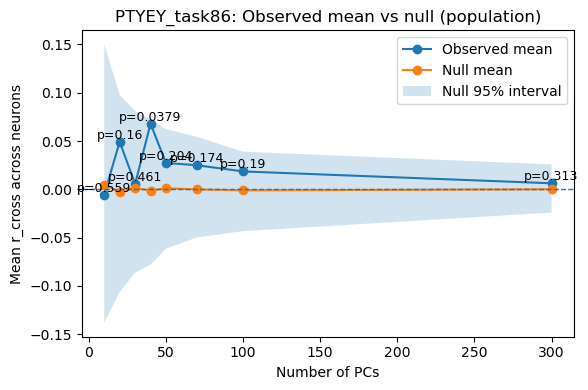

In [3]:
df, arr = load_patient_outputs(PATIENT_ID, BASE_RESULTS_ROOT, WINDOW_NAME)

rows = []

for pc in PC_LIST:
    mean_obs, mean_null, _ = mean_obs_and_mean_null(df, arr, pc)

    if mean_null is None or not np.isfinite(mean_obs):
        continue

    # clean null
    mean_null = mean_null[np.isfinite(mean_null)]
    n_null = len(mean_null)

    # exact permutation p-value
    n_extreme = np.sum(mean_null >= mean_obs)
    p_pop = (n_extreme + 1) / (n_null + 1)

    print("--------------------------------------------------")
    print(f"PC = {pc}")
    print(f"Observed mean      = {mean_obs:.6f}")
    print(f"Null mean          = {np.mean(mean_null):.6f}")
    print(f"Null std           = {np.std(mean_null):.6f}")
    print(f"Max null           = {np.max(mean_null):.6f}")
    print(f"Min null           = {np.min(mean_null):.6f}")
    print(f"# null >= observed = {n_extreme} / {n_null}")
    print(f"Population p-value = {p_pop:.8f}")
    print("--------------------------------------------------")

    rows.append({
        "n_pcs": pc,
        "mean_obs": mean_obs,
        "null_mean": float(np.mean(mean_null)),
        "null_lo": float(np.quantile(mean_null, 0.025)),
        "null_hi": float(np.quantile(mean_null, 0.975)),
        "p_pop": p_pop
    })

g = pd.DataFrame(rows).sort_values("n_pcs")

print("\nSummary table:")
print(g)

# ---------------- Plot ----------------
plt.figure(figsize=(6,4))

plt.plot(g["n_pcs"], g["mean_obs"], marker="o", label="Observed mean")
plt.plot(g["n_pcs"], g["null_mean"], marker="o", label="Null mean")
plt.fill_between(g["n_pcs"], g["null_lo"], g["null_hi"], alpha=0.2, label="Null 95% interval")

# Annotate p-values above each observed point
for _, r in g.iterrows():
    plt.text(
        r["n_pcs"],
        r["mean_obs"],
        f"p={r['p_pop']:.3g}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Number of PCs")
plt.ylabel("Mean r_cross across neurons")
plt.title(f"{PATIENT_ID}: Observed mean vs null (population)")
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_2613997/1619923038.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", len(PC_LIST))


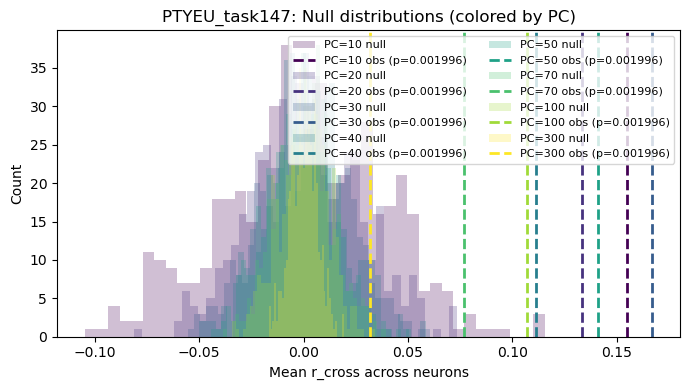

In [25]:
df, arr = load_patient_outputs(PATIENT_ID, BASE_RESULTS_ROOT, WINDOW_NAME)

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np


cmap = cm.get_cmap("viridis", len(PC_LIST))
colors = [cmap(i) for i in range(len(PC_LIST))]

plt.figure(figsize=(7,4))

for idx, pc in enumerate(PC_LIST):
    mean_obs, mean_null, p_pop = mean_obs_and_mean_null(df, arr, pc)
    if mean_null is None or not np.isfinite(mean_obs):
        continue

    color = colors[idx]

    # null histogram
    plt.hist(
        mean_null[np.isfinite(mean_null)],
        bins=BINS,
        alpha=0.25,
        color=color,
        label=f"PC={pc} null"
    )

    # observed mean (colored dashed line)
    plt.axvline(
        mean_obs,
        linestyle="--",
        linewidth=2,
        color=color,
        label=f"PC={pc} obs (p={p_pop:.4g})"
    )

plt.xlabel("Mean r_cross across neurons")
plt.ylabel("Count")
plt.title(f"{PATIENT_ID}: Null distributions (colored by PC)")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()



========== PC = 10 ==========
PTYEU_task147: obs=0.1549
PTYEY_task86: obs=-0.0053
PTYFK_task40: obs=0.0721
PTYFA_task25: obs=-0.0169
PTYFF_task17: obs=0.1127
PTYFG_task18: obs=-0.0236
PTYFC_task28: obs=-0.0044
PTYFI_task81: obs=0.1664
PTYEZ_task60: obs=0.4142
PTYEV_task37: obs=0.1235
GROUP OBS = 0.099344
GROUP NULL MEAN = 0.000792
P VALUE = 0.00199601

========== PC = 20 ==========
PTYEU_task147: obs=0.1333
PTYEY_task86: obs=0.0492
PTYFK_task40: obs=0.1917
PTYFA_task25: obs=0.0274
PTYFF_task17: obs=0.1417
PTYFG_task18: obs=0.0241
PTYFC_task28: obs=0.1959
PTYFI_task81: obs=0.1684
PTYEZ_task60: obs=0.4132
PTYEV_task37: obs=0.0332
GROUP OBS = 0.137808
GROUP NULL MEAN = 0.000081
P VALUE = 0.00199601

========== PC = 30 ==========
PTYEU_task147: obs=0.1668
PTYEY_task86: obs=0.0056
PTYFK_task40: obs=0.1337
PTYFA_task25: obs=0.0481
PTYFF_task17: obs=0.1201
PTYFG_task18: obs=0.0355
PTYFC_task28: obs=0.1866
PTYFI_task81: obs=0.1405
PTYEZ_task60: obs=0.4110
PTYEV_task37: obs=0.0722
GROUP OBS = 

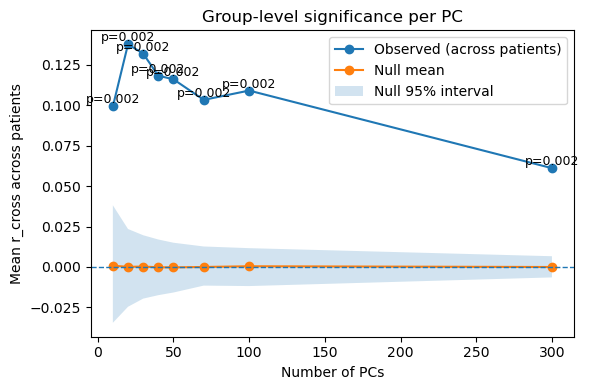

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PATIENT_IDS = [
    "PTYEU_task147",
    "PTYEY_task86",
    "PTYFK_task40",
    "PTYFA_task25",
    "PTYFF_task17",
    "PTYFG_task18",
    "PTYFC_task28",
    "PTYFI_task81",
    "PTYEZ_task60",
    "PTYEV_task37",
]

BASE_RESULTS_ROOT = "/projects/bhayden/anilu/Language_docs/PC_SWEEPS_BETA_REL_MAINPIPELINE"
WINDOW_NAME = "tshift-150_tlen500_oshift+200_olen500"
PC_LIST = [10, 20, 30, 40, 50, 70, 100, 300]
BINS = 40


def load_patient_outputs(patient_id):
    scalars_path = os.path.join(
        BASE_RESULTS_ROOT, patient_id, WINDOW_NAME,
        f"{patient_id}_pc_sweep_full_scalars.csv"
    )
    arrays_path = os.path.join(
        BASE_RESULTS_ROOT, patient_id, WINDOW_NAME,
        f"{patient_id}_pc_sweep_full_arrays.npz"
    )

    df = pd.read_csv(scalars_path)
    arr = np.load(arrays_path, allow_pickle=True)["data"]
    return df, arr


def get_patient_pc_stats(df, arr, pc):
    df_pc = df[(df["n_pcs"] == pc) & (df["failed"] == False)].copy()
    if len(df_pc) == 0:
        return None, None

    r_obs = df_pc["r_cross"].to_numpy(float)
    r_obs = r_obs[np.isfinite(r_obs)]
    if len(r_obs) == 0:
        return None, None

    mean_obs = np.mean(r_obs)

    # build null
    idx = df_pc.index.to_numpy()
    null_mat = []
    for i in idx:
        d = arr[i]
        if isinstance(d, dict) and ("null_r" in d) and (d["null_r"] is not None):
            nr = np.asarray(d["null_r"], dtype=float)
            nr = nr[np.isfinite(nr)]
            if len(nr) > 0:
                null_mat.append(nr)

    if len(null_mat) == 0:
        return None, None

    min_len = min(len(x) for x in null_mat)
    null_mat = np.vstack([x[:min_len] for x in null_mat])  # neurons x N_NULL

    mean_null = np.mean(null_mat, axis=0)  # N_NULL

    return mean_obs, mean_null


# ============================================================
# GROUP ANALYSIS PER PC
# ============================================================
rows = []

for pc in PC_LIST:
    patient_obs = []
    patient_nulls = []

    print(f"\n========== PC = {pc} ==========")

    for pid in PATIENT_IDS:
        try:
            df, arr = load_patient_outputs(pid)
            mean_obs, mean_null = get_patient_pc_stats(df, arr, pc)

            if mean_obs is None or mean_null is None:
                print(f"{pid}: skipped")
                continue

            patient_obs.append(mean_obs)
            patient_nulls.append(mean_null)

            print(f"{pid}: obs={mean_obs:.4f}")

        except Exception as e:
            print(f"{pid}: ERROR -> {e}")

    if len(patient_obs) == 0:
        print("No valid patients for this PC")
        continue

    # align null lengths
    min_len = min(len(x) for x in patient_nulls)
    null_stack = np.vstack([x[:min_len] for x in patient_nulls])  # patients x N_NULL

    group_obs = np.mean(patient_obs)
    group_null = np.mean(null_stack, axis=0)

    p_val = (np.sum(group_null >= group_obs) + 1) / (len(group_null) + 1)

    print(f"GROUP OBS = {group_obs:.6f}")
    print(f"GROUP NULL MEAN = {np.mean(group_null):.6f}")
    print(f"P VALUE = {p_val:.8f}")

    rows.append({
        "n_pcs": pc,
        "group_obs": group_obs,
        "null_mean": float(np.mean(group_null)),
        "null_lo": float(np.quantile(group_null, 0.025)),
        "null_hi": float(np.quantile(group_null, 0.975)),
        "p_val": p_val,
        "n_patients": len(patient_obs)
    })

g = pd.DataFrame(rows).sort_values("n_pcs")

print("\nFINAL TABLE:")
print(g)


# ============================================================
# PLOT
# ============================================================
plt.figure(figsize=(6, 4))

plt.plot(g["n_pcs"], g["group_obs"], marker="o", label="Observed (across patients)")
plt.plot(g["n_pcs"], g["null_mean"], marker="o", label="Null mean")

plt.fill_between(
    g["n_pcs"],
    g["null_lo"],
    g["null_hi"],
    alpha=0.2,
    label="Null 95% interval"
)

for _, r in g.iterrows():
    plt.text(
        r["n_pcs"],
        r["group_obs"],
        f"p={r['p_val']:.3g}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Number of PCs")
plt.ylabel("Mean r_cross across patients")
plt.title("Group-level significance per PC")
plt.legend()
plt.tight_layout()
plt.show()

# This plots multiple patients

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ----------------------------
# EDIT ME
# ----------------------------
PATIENT_IDS = [
    "PTYEU_task147",
    "PTYEY_task86",
    "PTYFK_task40",
    "PTYFA_task25",
    "PTYFF_task17",
    "PTYFG_task18",
    "PTYFC_task28",
    "PTYFI_task81",
    "PTYEZ_task60",
    "PTYEV_task37",
        # ...
]

BASE_RESULTS_ROOT = "/projects/bhayden/anilu/Language_docs/PC_SWEEPS_BETA_REL_MAINPIPELINE"
WINDOW_NAME = "tshift-150_tlen500_oshift+200_olen500"
BINS = 40

# Optional filters
FILTER_FAILED = True           # drop failed rows
FILTER_SIGNIFICANT_NEURONS = False  # if True: keep only p_null < 0.05 (per-neuron)
SIG_THRESH = 0.05

# ----------------------------
# Helpers
# ----------------------------
def load_patient_outputs(patient_id: str, base_root: str, window_name: str):
    out_dir = os.path.join(base_root, patient_id, window_name)
    scalars_path = os.path.join(out_dir, f"{patient_id}_pc_sweep_full_scalars.csv")
    arrays_path = os.path.join(out_dir, f"{patient_id}_pc_sweep_full_arrays.npz")

    if not os.path.exists(scalars_path):
        raise FileNotFoundError(f"Missing scalars CSV: {scalars_path}")
    if not os.path.exists(arrays_path):
        raise FileNotFoundError(f"Missing arrays NPZ: {arrays_path}")

    df = pd.read_csv(scalars_path)
    arr = np.load(arrays_path, allow_pickle=True)["data"]
    return df, arr, out_dir


def mean_obs_and_mean_null(df: pd.DataFrame, arr: np.ndarray, n_pcs: int):
    """
    Returns:
      mean_obs: float
      mean_null: np.ndarray shape (N_NULL,)   [population mean per null draw]
      p_pop: float (exact permutation p)
      stats: dict with debug quantities
    """
    df_pc = df[df["n_pcs"] == n_pcs].copy()

    if FILTER_FAILED and "failed" in df_pc.columns:
        df_pc = df_pc[df_pc["failed"] == False]

    if FILTER_SIGNIFICANT_NEURONS and "p_null" in df_pc.columns:
        df_pc = df_pc[df_pc["p_null"] < SIG_THRESH]

    if len(df_pc) == 0:
        return np.nan, None, np.nan, {}

    r_obs = df_pc["r_cross"].to_numpy(dtype=float)
    r_obs = r_obs[np.isfinite(r_obs)]
    if len(r_obs) == 0:
        return np.nan, None, np.nan, {}

    mean_obs = float(np.mean(r_obs))

    # Pull null_r arrays for these same rows (assumes CSV and NPZ were written in same run/order)
    idx = df_pc.index.to_numpy()
    null_list = []
    for i in idx:
        d = arr[i]
        if isinstance(d, dict) and ("null_r" in d) and (d["null_r"] is not None):
            null_list.append(np.asarray(d["null_r"], dtype=float))

    if len(null_list) == 0:
        return mean_obs, None, np.nan, {"n_neurons": int(len(r_obs))}

    null_mat = np.vstack(null_list)              # neurons x N_NULL
    mean_null = np.nanmean(null_mat, axis=0)     # N_NULL

    mean_null = mean_null[np.isfinite(mean_null)]
    n_null = len(mean_null)
    n_extreme = int(np.sum(mean_null >= mean_obs))
    p_pop = float((n_extreme + 1) / (n_null + 1)) if n_null > 0 else np.nan

    stats = {
        "n_neurons": int(len(r_obs)),
        "n_null": int(n_null),
        "n_extreme": int(n_extreme),
        "null_mean": float(np.mean(mean_null)) if n_null > 0 else np.nan,
        "null_std": float(np.std(mean_null)) if n_null > 0 else np.nan,
        "null_min": float(np.min(mean_null)) if n_null > 0 else np.nan,
        "null_max": float(np.max(mean_null)) if n_null > 0 else np.nan,
    }
    return mean_obs, mean_null, p_pop, stats


def plot_overlay_nulls(patient_id: str, rows: pd.DataFrame, save_path: str, bins: int = 40):
    """
    rows must contain columns: n_pcs, mean_obs, p_pop, mean_null (as object arrays or None)
    """
    pcs = list(rows["n_pcs"])
    cmap = cm.get_cmap("viridis", len(pcs))
    colors = [cmap(i) for i in range(len(pcs))]

    plt.figure(figsize=(8, 4.5))

    for k, pc in enumerate(pcs):
        mean_null = rows.loc[rows["n_pcs"] == pc, "mean_null"].iloc[0]
        mean_obs = float(rows.loc[rows["n_pcs"] == pc, "mean_obs"].iloc[0])
        p_pop = float(rows.loc[rows["n_pcs"] == pc, "p_pop"].iloc[0])

        if mean_null is None or not np.isfinite(mean_obs):
            continue

        color = colors[k]
        mean_null = np.asarray(mean_null, dtype=float)
        mean_null = mean_null[np.isfinite(mean_null)]

        plt.hist(mean_null, bins=bins, alpha=0.18, color=color, label=f"PC={pc} null")
        plt.axvline(mean_obs, linestyle="--", linewidth=2, color=color, label=f"PC={pc} obs p={p_pop:.3g}")

    plt.xlabel("Mean r_cross across neurons")
    plt.ylabel("Count")
    plt.title(f"{patient_id}: Population mean vs null (overlay)")
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.close()


def plot_curve_obs_vs_null(patient_id: str, g: pd.DataFrame, save_path: str):
    """
    g columns: n_pcs, mean_obs, null_mean, null_lo, null_hi, p_pop
    """
    plt.figure(figsize=(6.5, 4.5))

    plt.plot(g["n_pcs"], g["mean_obs"], marker="o", label="Observed mean")
    plt.plot(g["n_pcs"], g["null_mean"], marker="o", label="Null mean")
    plt.fill_between(g["n_pcs"], g["null_lo"], g["null_hi"], alpha=0.2, label="Null 95% interval")
    plt.axhline(0, linestyle="--", linewidth=1)

    for _, r in g.iterrows():
        plt.text(r["n_pcs"], r["mean_obs"], f"p={r['p_pop']:.3g}", ha="center", va="bottom", fontsize=9)

    plt.xlabel("Number of PCs")
    plt.ylabel("Mean r_cross across neurons")
    plt.title(f"{patient_id}: Observed mean vs null")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.close()


# ----------------------------
# Main loop over patients
# ----------------------------
def run_all_patients():
    for pid in PATIENT_IDS:
        try:
            df, arr, out_dir = load_patient_outputs(pid, BASE_RESULTS_ROOT, WINDOW_NAME)

            pcs = PC_LIST
            if pcs is None:
                pcs = sorted(df["n_pcs"].unique().tolist())

            # compute per-PC population stats
            rows = []
            for pc in pcs:
                mean_obs, mean_null, p_pop, stats = mean_obs_and_mean_null(df, arr, pc)
                if mean_null is None or not np.isfinite(mean_obs):
                    continue

                rows.append({
                    "patient_ID": pid,
                    "n_pcs": int(pc),
                    "mean_obs": float(mean_obs),
                    "p_pop": float(p_pop),
                    "n_neurons": stats.get("n_neurons", np.nan),
                    "n_null": stats.get("n_null", np.nan),
                    "n_extreme": stats.get("n_extreme", np.nan),
                    "null_mean": stats.get("null_mean", np.nan),
                    "null_std": stats.get("null_std", np.nan),
                    "null_min": stats.get("null_min", np.nan),
                    "null_max": stats.get("null_max", np.nan),
                    "null_lo": float(np.quantile(mean_null, 0.025)),
                    "null_hi": float(np.quantile(mean_null, 0.975)),
                    "mean_null": mean_null,  # keep full vector for overlay plot
                })

            if len(rows) == 0:
                print(f"[{pid}] No valid PC rows to plot.")
                continue

            rows_df = pd.DataFrame(rows).sort_values("n_pcs")

            # Save summary table WITHOUT the large mean_null vectors
            summary = rows_df.drop(columns=["mean_null"]).copy()
            summary_path = os.path.join(out_dir, f"{pid}_population_mean_vs_null.csv")
            summary.to_csv(summary_path, index=False)

            # Overlay figure (uses mean_null vectors)
            overlay_path = os.path.join(out_dir, f"{pid}_overlay_null_hist_by_pc.png")
            plot_overlay_nulls(pid, rows_df[["n_pcs", "mean_obs", "p_pop", "mean_null"]], overlay_path, bins=BINS)

            # Curve figure
            g = rows_df[["n_pcs", "mean_obs", "null_mean", "null_lo", "null_hi", "p_pop"]].copy()
            curve_path = os.path.join(out_dir, f"{pid}_curve_obs_vs_null.png")
            plot_curve_obs_vs_null(pid, g, curve_path)

            print(f"[{pid}] saved:")
            print(f"  - {summary_path}")
            print(f"  - {overlay_path}")
            print(f"  - {curve_path}")

        except Exception as e:
            print(f"[{pid}] FAILED: {e}")


if __name__ == "__main__":
    run_all_patients()


[PTYEU_task147] FAILED: name 'PC_LIST' is not defined
[PTYEY_task86] FAILED: name 'PC_LIST' is not defined
[PTYFK_task40] FAILED: name 'PC_LIST' is not defined
[PTYFA_task25] FAILED: name 'PC_LIST' is not defined
[PTYFF_task17] FAILED: name 'PC_LIST' is not defined
[PTYFG_task18] FAILED: name 'PC_LIST' is not defined
[PTYFC_task28] FAILED: name 'PC_LIST' is not defined
[PTYFI_task81] FAILED: name 'PC_LIST' is not defined
[PTYEZ_task60] FAILED: name 'PC_LIST' is not defined
[PTYEV_task37] FAILED: name 'PC_LIST' is not defined


# Correlating beta weights

In [13]:
def fit_one_neuron_betas_only(Xs, Ys, Xo, Yo, j, fcfg, alpha_cfg, backend):
    ys = np.asarray(Ys[:, j], dtype=float)
    yo = np.asarray(Yo[:, j], dtype=float)

    if (
        np.std(ys) == 0
        or np.std(yo) == 0
        or (not np.all(np.isfinite(ys)))
        or (not np.all(np.isfinite(yo)))
    ):
        return {
            "neuron": j,
            "failed": True,
            "beta_self": None,
            "beta_other": None,
            "alpha_self": np.nan,
            "alpha_other": np.nan,
        }

    if USE_SHARED_ALPHA:
        X_pool = np.vstack([Xs, Xo])
        y_pool = np.concatenate([ys, yo])

        X_pool_s, _, _ = reg.standardize_train_test(
            X_pool, X_pool, do_standardize=fcfg.standardize
        )
        a_shared = choose_alpha_mainpipeline(X_pool_s, y_pool, alpha_cfg, backend)
        aS = a_shared
        aO = a_shared
    else:
        Xs_s, _, _ = reg.standardize_train_test(Xs, Xs, do_standardize=fcfg.standardize)
        Xo_s, _, _ = reg.standardize_train_test(Xo, Xo, do_standardize=fcfg.standardize)

        aS = choose_alpha_mainpipeline(Xs_s, ys, alpha_cfg, backend)
        aO = choose_alpha_mainpipeline(Xo_s, yo, alpha_cfg, backend)

    bS = fit_beta_given_alpha_mainpipeline(Xs, ys, fcfg, aS, backend)
    bO = fit_beta_given_alpha_mainpipeline(Xo, yo, fcfg, aO, backend)

    return {
        "neuron": j,
        "failed": False,
        "beta_self": bS.astype(float, copy=False),
        "beta_other": bO.astype(float, copy=False),
        "alpha_self": float(aS),
        "alpha_other": float(aO),
    }


In [37]:
def fit_one_neuron_betas_with_other_null(
    Xs, Ys, Xo, Yo, j, fcfg, alpha_cfg, backend,
    n_null=500,
    null_mode="row_permute_X",
    seed=0,
):
    ys = np.asarray(Ys[:, j], dtype=float)
    yo = np.asarray(Yo[:, j], dtype=float)

    if (
        np.std(ys) == 0
        or np.std(yo) == 0
        or (not np.all(np.isfinite(ys)))
        or (not np.all(np.isfinite(yo)))
    ):
        return {
            "neuron": j,
            "failed": True,
            "beta_self": None,
            "beta_other": None,
            "alpha_self": np.nan,
            "alpha_other": np.nan,
            "r_obs": np.nan,
            "r_null": None,
            "p_perm": np.nan,
        }

    # choose alpha(s)
    if USE_SHARED_ALPHA:
        X_pool = np.vstack([Xs, Xo])
        y_pool = np.concatenate([ys, yo])

        X_pool_s, _, _ = reg.standardize_train_test(
            X_pool, X_pool, do_standardize=fcfg.standardize
        )
        a_shared = choose_alpha_mainpipeline(X_pool_s, y_pool, alpha_cfg, backend)
        aS = a_shared
        aO = a_shared
    else:
        Xs_s, _, _ = reg.standardize_train_test(Xs, Xs, do_standardize=fcfg.standardize)
        Xo_s, _, _ = reg.standardize_train_test(Xo, Xo, do_standardize=fcfg.standardize)

        aS = choose_alpha_mainpipeline(Xs_s, ys, alpha_cfg, backend)
        aO = choose_alpha_mainpipeline(Xo_s, yo, alpha_cfg, backend)

    # fit real betas
    bS = fit_beta_given_alpha_mainpipeline(Xs, ys, fcfg, aS, backend)
    bO = fit_beta_given_alpha_mainpipeline(Xo, yo, fcfg, aO, backend)

    r_obs = reg.safe_corr(bS[:fcfg.n_pcs], bO[:fcfg.n_pcs], kind="pearson")

    # build OTHER null
    rng = np.random.default_rng(seed + j)
    r_null = np.full(n_null, np.nan, dtype=float)

    for k in range(n_null):
        Xo_null = Xo.copy()
        yo_null = yo.copy()

        if null_mode == "row_permute_X":
            Xo_null = Xo_null[rng.permutation(Xo_null.shape[0])]
        elif null_mode == "shuffle_y":
            yo_null = yo_null[rng.permutation(yo_null.shape[0])]
        else:
            raise ValueError("null_mode must be 'row_permute_X' or 'shuffle_y'")

        bO_null = fit_beta_given_alpha_mainpipeline(Xo_null, yo_null, fcfg, aO, backend)
        r_null[k] = reg.safe_corr(bS[:fcfg.n_pcs], bO_null[:fcfg.n_pcs], kind="pearson")

    p_perm = (1.0 + np.sum(r_null >= r_obs)) / (n_null + 1.0)

    return {
        "neuron": j,
        "failed": False,
        "beta_self": bS.astype(float, copy=False),
        "beta_other": bO.astype(float, copy=False),
        "alpha_self": float(aS),
        "alpha_other": float(aO),
        "r_obs": float(r_obs),
        "r_null": r_null,
        "p_perm": float(p_perm),
    }

In [38]:
def run_one_patient(patient_cfg):
    pid = patient_cfg["patient_ID"]
    paths = get_paths_local(pid, patient_cfg["prefix"])

    out_dir = os.path.join(RESULTS_ROOT, pid, WINDOW_CFG["name"])
    os.makedirs(out_dir, exist_ok=True)

    for n_pcs in PC_LIST:
        print(f"\n=== {pid} | PCs={n_pcs} ===")

        xy = build_XY_for_one_pc(
            paths,
            patient_cfg,
            n_pcs,
            REGIONS,
            target_speaker=TARGET_SPEAKER,
            agg="sum",
        )

        for region in REGIONS:
            d = xy.get(region)
            if d is None:
                print(f"Skipping {pid} {region} (no data)")
                continue

            Xs, Ys = d["X_self"], d["Y_self"]
            Xo, Yo = d["X_other"], d["Y_other"]
            fcfg = d["fcfg"]

            print(f"  {region}: Xs{Xs.shape} Ys{Ys.shape} | Xo{Xo.shape} Yo{Yo.shape}")

            n_null = 500

            rows_raw: Any = Parallel(
                n_jobs=N_JOBS,
                prefer="processes",
                verbose=10
            )(
                delayed(fit_one_neuron_betas_with_other_null)(
                    Xs, Ys, Xo, Yo, j, fcfg, ALPHA_CFG, BACKEND,
                    n_null=n_null,
                    null_mode="row_permute_X",
                    seed=12345,
                )
                for j in range(Ys.shape[1])
            )

            rows = cast(List[Dict[str, Any]], rows_raw)

            n_neurons = Ys.shape[1]
            n_features = Xs.shape[1]

            beta_self_mat = np.full((n_neurons, n_features), np.nan, dtype=float)
            beta_other_mat = np.full((n_neurons, n_features), np.nan, dtype=float)
            alpha_self = np.full(n_neurons, np.nan, dtype=float)
            alpha_other = np.full(n_neurons, np.nan, dtype=float)
            failed = np.ones(n_neurons, dtype=bool)

            # NEW: significance-related outputs
            r_obs = np.full(n_neurons, np.nan, dtype=float)
            p_perm = np.full(n_neurons, np.nan, dtype=float)
            r_null = np.full((n_neurons, n_null), np.nan, dtype=float)

            for r in rows:
                j = int(r["neuron"])
                failed[j] = bool(r["failed"])
                alpha_self[j] = r.get("alpha_self", np.nan)
                alpha_other[j] = r.get("alpha_other", np.nan)

                if not r["failed"]:
                    beta_self_mat[j, :] = r["beta_self"]
                    beta_other_mat[j, :] = r["beta_other"]
                    r_obs[j] = r["r_obs"]
                    p_perm[j] = r["p_perm"]
                    r_null[j, :] = r["r_null"]

            # Optional summary per patient-region
            valid = (~failed) & np.isfinite(r_obs) & np.isfinite(p_perm)
            sig_pos = valid & (r_obs > 0) & (p_perm < 0.05)

            n_valid = int(valid.sum())
            k_sig = int(sig_pos.sum())
            prop_sig = (k_sig / n_valid) if n_valid > 0 else np.nan

            print(
                f"  {region}: n_valid={n_valid}, "
                f"k_sig_pos={k_sig}, prop_sig_pos={prop_sig:.3f}"
                if np.isfinite(prop_sig) else
                f"  {region}: n_valid={n_valid}, k_sig_pos={k_sig}, prop_sig_pos=nan"
            )

            save_path = os.path.join(
                out_dir,
                f"{pid}_{region}_pc{n_pcs}_betas.npz"
            )

            np.savez_compressed(
                save_path,
                beta_self=beta_self_mat,
                beta_other=beta_other_mat,
                alpha_self=alpha_self,
                alpha_other=alpha_other,
                failed=failed,
                r_obs=r_obs,           # observed beta correlation per neuron
                p_perm=p_perm,         # permutation p-value per neuron
                r_null=r_null,         # null distribution per neuron
                patient_ID=pid,
                region=region,
                window_name=WINDOW_CFG["name"],
                n_pcs=n_pcs,
                n_self_trials=Xs.shape[0],
                n_other_trials=Xo.shape[0],
                n_features=n_features,
                n_valid=n_valid,
                k_sig_pos=k_sig,
                prop_sig_pos=prop_sig,
            )

            print(f"Saved beta weights + permutation results: {save_path}")

In [56]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd

# Your refactored code (adjust module name if needed)
from neural_encoding import regression as reg
from neural_encoding import reliability as rel
from neural_encoding import spike_processing as spu

from typing import Any, Dict, List, cast
import numpy as np
import pandas as pd
from joblib import Parallel, delayed


# =========================
# CONFIG (EDIT ME)
# =========================
PATIENTS = [
    # {
    #     "patient_ID": "PTYFF_task17",
    #     "prefix": "ptYFF_task17",
    #     "region_ranges": {
    #          "hippocampus": [(9,16),(25,40)],
    #             "ACC": [(17,24),(41,48)]
    #     }
    # },
    # {
    #     "patient_ID": "PTYEU_task147",
    #     "prefix": "ptYEU_task147",
    #     "region_ranges": {
    #         "hippocampus": [(1, 16), (25, 40)],
    #         "ACC": [(17, 24), (41, 48)]
    #     }
    # },
    # {
    #     "patient_ID": "PTYFC_task28",
    #     "prefix": "ptYFC_task28",
    #     "region_ranges": {
    #         "hippocampus": [(1,8),(33,48)],
    #             "ACC": [(17,32),(49,64)]
    #     }
    # },
    #     {
    #     "patient_ID": "PTYEV_task37",
    #     "prefix": "ptYEV_task37",
    #     "region_ranges": {
    #          "hippocampus": [(1,16),(25,40)],
    #             "ACC": [(17,24),(41,48)]
    #     }
    # },
    #     {
    #     "patient_ID": "PTYEZ_task60",
    #     "prefix": "ptYEZ_task60",
    #     "region_ranges": {
    #          "hippocampus": [(1,16)],
    #             "ACC": [(17,24)]
    #     }
    # },
    #     {
    #     "patient_ID": "PTYFG_task18",
    #     "prefix": "ptYFG_task18",
    #     "region_ranges": {
    #         "hippocampus": [(9,16)],
    #          "ACC": [(25,56)]
    #     }
    # },
    # {
    #     "patient_ID": "PTYFK_task40",
    #     "prefix": "ptYFK_task40",
    #     "region_ranges": {
    #         "hippocampus": [(1,16),(25,40)],
    #             "ACC": [(49,56)],
    #     }
    # },
    #        {
    #     "patient_ID": "PTYFI_task81",
    #     "prefix": "ptYFI_task81",
    #     "region_ranges": {
    #            "hippocampus": [(1,8),(25,40)],
    #             "ACC": [(9,16)]
    #     }
    # },
            {
        "patient_ID": "PTYFA_task25",
        "prefix": "ptYFA_task25",
        "region_ranges": {
            "hippocampus": [(1,16),(25,40)],
                "ACC": [(17,24)],
        }
    },
    {
        "patient_ID": "PTYEY_task86",
        "prefix": "ptYEY_task86",
        "region_ranges": {
              "hippocampus": [(1,16)],
             
        }
    },
]

BALANCE_OTHER_TO_SELF = True
BALANCE_MAX_RATIO = 1.5    # other trials <= ratio * self trials

USE_SHARED_ALPHA = True     # if False → separate alphas (current behavior)

ALPHA_CFG = reg.AlphaConfig(
    alphas=np.logspace(-6, 3, 40),
    inner_cv=reg.SplitConfig(
        method="contiguous_kfold",
        n_splits=5,
        shuffle=False,
        random_state=0
    )
)

REGIONS = ["hippocampus"]  # or ["hippocampus","ACC"]

ROOT_SPIKES = "/projects/bhayden/anilu/Language_docs/Regression/SpikesMAT"
RESULTS_ROOT = "/projects/bhayden/anilu/Language_docs/BETA_WEIGHTS_ALL_PATIENTS"

PC_LIST = [200]


WINDOW_CFG = {
    "name": "tshift-150_tlen500_oshift+200_olen500",
    "mode": "target_vs_other_fixed_window_from_ref",
    "speaker_of_interest": "Speaker1",
    "target_ref_point": "onset",
    "target_shift": -150,
    "target_window_length": 500,
    "other_ref_point": "onset",
    "other_shift": 200,
    "other_window_length": 500,
}

# Duration in X?
DURATION_CHOICE = "none"        # "none" | "word_dur" | "regress_dur"
INCLUDE_INTERACTIONS = False    # only relevant if DURATION_CHOICE != "none"

# Alpha selection: contiguous is better for sequential word streams
ALPHA_CFG = reg.AlphaConfig(
    alphas=np.logspace(-3, 3, 30),
    inner_cv=reg.SplitConfig(
        method="contiguous_kfold",
        n_splits=5,
        shuffle=False,
        random_state=0   # harmless even if shuffle=False
    )
)

# Null shuffle: choose based on whether duration is included
if DURATION_CHOICE == "none":
    X_SHUFFLE_MODE = "row_permute"
else:
    X_SHUFFLE_MODE = "semantic_columns"  # preserves duration covariate while breaking semantics

# Ceiling split: contiguous is better for time structure
HALF_SPLIT_MODE = "contiguous"

TARGET_SPEAKER = "SPK1"

In [40]:
def main():
    os.makedirs(RESULTS_ROOT, exist_ok=True)

    for p in PATIENTS:
        try:
            run_one_patient(p)
        except Exception as e:
            print(f"\n!!! FAILED patient {p['patient_ID']}: {e}")

if __name__ == "__main__":
    main()


=== PTYFF_task17 | PCs=200 ===

✅ Word counts after extraction:
Speaker1: 1500
Speaker2: 2738
Speaker3: 1851
[PTYFF_task17|hippocampus|PC200] Balanced OTHER: 4589 → 2250
  hippocampus: Xs(1500, 200) Ys(1500, 40) | Xo(2250, 200) Yo(2250, 40)


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:   49.5s
[Parallel(n_jobs=12)]: Done   8 tasks      | elapsed:  1.0min
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:  2.1min
[Parallel(n_jobs=12)]: Done  22 out of  40 | elapsed:  2.8min remaining:  2.3min
[Parallel(n_jobs=12)]: Done  27 out of  40 | elapsed:  3.0min remaining:  1.4min
[Parallel(n_jobs=12)]: Done  32 out of  40 | elapsed:  3.1min remaining:   47.2s
[Parallel(n_jobs=12)]: Done  37 out of  40 | elapsed:  3.5min remaining:   17.1s
[Parallel(n_jobs=12)]: Done  40 out of  40 | elapsed:  3.6min finished


  hippocampus: n_valid=40, k_sig_pos=13, prop_sig_pos=0.325
Saved beta weights + permutation results: /projects/bhayden/anilu/Language_docs/BETA_WEIGHTS_ALL_PATIENTS/PTYFF_task17/tshift-150_tlen500_oshift+200_olen500/PTYFF_task17_hippocampus_pc200_betas.npz

=== PTYEU_task147 | PCs=200 ===

✅ Word counts after extraction:
Speaker3: 1559
Speaker2: 11
Speaker1: 652
Speaker4: 74
Speaker5: 1752
Speaker6: 87
Speaker7: 310
[PTYEU_task147|hippocampus|PC200] Balanced OTHER: 3793 → 978
  hippocampus: Xs(652, 200) Ys(652, 77) | Xo(978, 200) Yo(978, 77)


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
/home/agc10/update_regressionpipeline.py:109: RuntimeWarning: invalid value encountered in multiply
  return float(np.sum(y * np.log(mu) - mu - gammaln(y + 1)))
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:   24.6s
[Parallel(n_jobs=12)]: Done   8 tasks      | elapsed:   37.6s
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:  1.2min
/home/agc10/update_regressionpipeline.py:109: RuntimeWarning: invalid value encountered in multiply
  return float(np.sum(y * np.log(mu) - mu - gammaln(y + 1)))
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:  1.9min
[Parallel(n_jobs=12)]: Done  37 tasks      | elapsed:  2.6min
[Parallel(n_jobs=12)]: Done  48 tasks      | elapsed:  3.3min
[Parallel(n_jobs=12)]: Done  62 out of  77 | elapsed:  4.0min remaining:   58.6s
[Parallel(n_jobs=12)]: Done  70 out of  77 | elapsed:  4.4min remaining:   26.4s
[Parallel(n_jobs=12)]: Done  77 out of  77 | elapsed:  4.7min finis

  hippocampus: n_valid=77, k_sig_pos=20, prop_sig_pos=0.260
Saved beta weights + permutation results: /projects/bhayden/anilu/Language_docs/BETA_WEIGHTS_ALL_PATIENTS/PTYEU_task147/tshift-150_tlen500_oshift+200_olen500/PTYEU_task147_hippocampus_pc200_betas.npz

=== PTYFC_task28 | PCs=200 ===

✅ Word counts after extraction:
Speaker6: 44
Speaker4: 77
Speaker2: 2081
Speaker3: 31
Speaker1: 1204
Speaker5: 107
[PTYFC_task28|hippocampus|PC200] Balanced OTHER: 2337 → 1806
  hippocampus: Xs(1204, 200) Ys(1204, 34) | Xo(1806, 200) Yo(1806, 34)


...

[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:   17.8s
[Parallel(n_jobs=12)]: Done   8 tasks      | elapsed:   39.9s
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:  1.3min
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:  1.7min
[Parallel(n_jobs=12)]: Done  37 tasks      | elapsed:  2.4min
[Parallel(n_jobs=12)]: Done  53 out of  69 | elapsed:  3.2min remaining:   57.5s
/home/agc10/update_regressionpipeline.py:109: RuntimeWarning: invalid value encountered in multiply
  return float(np.sum(y * np.log(mu) - mu - gammaln(y + 1)))
[Parallel(n_jobs=12)]: Done  60 out of  69 | elapsed:  3.7min remaining:   33.5s
[Parallel(n_jobs=12)]: Done  67 out of  69 | elapsed:  3.8min remaining:    6.8s
[Parallel(n_jobs=12)]: Done  69 out of  69 | elapsed:  3.8min finished


  hippocampus: n_valid=69, k_sig_pos=3, prop_sig_pos=0.043
Saved beta weights + permutation results: /projects/bhayden/anilu/Language_docs/BETA_WEIGHTS_ALL_PATIENTS/PTYFA_task25/tshift-150_tlen500_oshift+200_olen500/PTYFA_task25_hippocampus_pc200_betas.npz

=== PTYEY_task86 | PCs=200 ===

✅ Word counts after extraction:
Speaker3: 1008
Speaker2: 1491
Speaker1: 67
Speaker4: 2219
Speaker5: 154
Speaker6: 73
Speaker7: 13
Speaker8: 37
Speaker9: 20
Speaker10: 518
Speaker11: 31
[PTYEY_task86|hippocampus|PC200] Balanced OTHER: 5564 → 100
  hippocampus: Xs(67, 200) Ys(67, 19) | Xo(100, 200) Yo(100, 19)


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   2 out of  19 | elapsed:   21.0s remaining:  3.0min
[Parallel(n_jobs=12)]: Done   4 out of  19 | elapsed:   24.1s remaining:  1.5min
[Parallel(n_jobs=12)]: Done   6 out of  19 | elapsed:   27.7s remaining:  1.0min
[Parallel(n_jobs=12)]: Done   8 out of  19 | elapsed:   28.5s remaining:   39.2s
[Parallel(n_jobs=12)]: Done  10 out of  19 | elapsed:   45.5s remaining:   40.9s
[Parallel(n_jobs=12)]: Done  12 out of  19 | elapsed:   47.6s remaining:   27.8s
[Parallel(n_jobs=12)]: Done  14 out of  19 | elapsed:   50.5s remaining:   18.0s
[Parallel(n_jobs=12)]: Done  16 out of  19 | elapsed:   51.1s remaining:    9.6s


  hippocampus: n_valid=19, k_sig_pos=0, prop_sig_pos=0.000
Saved beta weights + permutation results: /projects/bhayden/anilu/Language_docs/BETA_WEIGHTS_ALL_PATIENTS/PTYEY_task86/tshift-150_tlen500_oshift+200_olen500/PTYEY_task86_hippocampus_pc200_betas.npz


[Parallel(n_jobs=12)]: Done  19 out of  19 | elapsed:   51.5s finished


In [41]:
import os
import glob
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, binomtest


def safe_pearsonr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    r, p = pearsonr(x, y)
    return float(r), float(p)


def my_binom_test_py(k, n, p0=0.5, tail="right"):
    """
    Python version of your MATLAB myBinomTest.
    """
    if tail == "right":
        return binomtest(k, n, p=p0, alternative="greater").pvalue
    elif tail == "left":
        return binomtest(k, n, p=p0, alternative="less").pvalue
    elif tail == "two":
        return binomtest(k, n, p=p0, alternative="two-sided").pvalue
    else:
        raise ValueError("tail must be 'right', 'left', or 'two'")


def summarize_beta_correlations_for_file(npz_path, success_rule="r_gt_0", p0=0.5, tail="right"):
    z = np.load(npz_path, allow_pickle=True)

    beta_self = z["beta_self"]      # [neurons x features]
    beta_other = z["beta_other"]    # [neurons x features]
    failed = z["failed"]

    patient_ID = str(z["patient_ID"])
    region = str(z["region"])
    n_pcs = int(z["n_pcs"])
    window_name = str(z["window_name"])

    rows = []
    for j in range(beta_self.shape[0]):
        if failed[j]:
            rows.append({
                "patient_ID": patient_ID,
                "region": region,
                "window_name": window_name,
                "n_pcs": n_pcs,
                "neuron": j,
                "failed": True,
                "r_beta_self_other": np.nan,
                "p_pearson": np.nan,
                "success": np.nan,
            })
            continue

        r, p = safe_pearsonr(beta_self[j, :], beta_other[j, :])

        if success_rule == "r_gt_0":
            success = int(np.isfinite(r) and (r > 0))
        elif success_rule == "p_lt_0.05_and_r_gt_0":
            success = int(np.isfinite(r) and np.isfinite(p) and (r > 0) and (p < 0.05))
        else:
            raise ValueError("Unknown success_rule")

        rows.append({
            "patient_ID": patient_ID,
            "region": region,
            "window_name": window_name,
            "n_pcs": n_pcs,
            "neuron": j,
            "failed": False,
            "r_beta_self_other": r,
            "p_pearson": p,
            "success": success,
        })

    df = pd.DataFrame(rows)

    valid = df.loc[~df["failed"] & df["r_beta_self_other"].notna()].copy()
    k = int(valid["success"].sum())
    n = int(len(valid))

    binom_p = my_binom_test_py(k, n, p0=p0, tail=tail) if n > 0 else np.nan

    summary = {
        "patient_ID": patient_ID,
        "region": region,
        "window_name": window_name,
        "n_pcs": n_pcs,
        "n_valid_neurons": n,
        "k_success": k,
        "prop_success": (k / n) if n > 0 else np.nan,
        "binom_p": binom_p,
        "mean_r": float(valid["r_beta_self_other"].mean()) if n > 0 else np.nan,
        "median_r": float(valid["r_beta_self_other"].median()) if n > 0 else np.nan,
    }

    return df, summary


def run_all_beta_correlation_summaries(results_root, save_dir=None,
                                       success_rule="r_gt_0", p0=0.5, tail="right"):
    npz_files = sorted(glob.glob(os.path.join(results_root, "*", "*", "*_betas.npz")))

    all_neuron_dfs = []
    summary_rows = []

    for fp in npz_files:
        print(f"Processing: {fp}")
        df_neurons, summary = summarize_beta_correlations_for_file(
            fp,
            success_rule=success_rule,
            p0=p0,
            tail=tail
        )
        all_neuron_dfs.append(df_neurons)
        summary_rows.append(summary)

    df_all_neurons = pd.concat(all_neuron_dfs, ignore_index=True) if all_neuron_dfs else pd.DataFrame()
    df_summary = pd.DataFrame(summary_rows)

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

        neuron_csv = os.path.join(save_dir, "beta_vector_correlations_per_neuron.csv")
        summary_csv = os.path.join(save_dir, "beta_vector_binomial_summary.csv")

        df_all_neurons.to_csv(neuron_csv, index=False)
        df_summary.to_csv(summary_csv, index=False)

        print(f"Saved neuron-level results: {neuron_csv}")
        print(f"Saved summary results: {summary_csv}")

    return df_all_neurons, df_summary

In [42]:
RESULTS_ROOT = "/projects/bhayden/anilu/Language_docs/BETA_WEIGHTS_ALL_PATIENTS"
SAVE_DIR = "/projects/bhayden/anilu/Language_docs/BETA_WEIGHTS_ALL_PATIENTS/beta_corr_summary"

df_neurons, df_summary = run_all_beta_correlation_summaries(
    results_root=RESULTS_ROOT,
    save_dir=SAVE_DIR,
    success_rule="r_gt_0",   # success = beta correlation > 0
    p0=0.5,
    tail="right"
)

Processing: /projects/bhayden/anilu/Language_docs/BETA_WEIGHTS_ALL_PATIENTS/PTYEU_task147/tshift-150_tlen500_oshift+200_olen500/PTYEU_task147_hippocampus_pc200_betas.npz
Processing: /projects/bhayden/anilu/Language_docs/BETA_WEIGHTS_ALL_PATIENTS/PTYEU_task147/tshift-150_tlen500_oshift+200_olen500/PTYEU_task147_hippocampus_pc20_betas.npz
Processing: /projects/bhayden/anilu/Language_docs/BETA_WEIGHTS_ALL_PATIENTS/PTYEU_task147/tshift-150_tlen500_oshift+200_olen500/PTYEU_task147_hippocampus_pc50_betas.npz
Processing: /projects/bhayden/anilu/Language_docs/BETA_WEIGHTS_ALL_PATIENTS/PTYEV_task37/tshift-150_tlen500_oshift+200_olen500/PTYEV_task37_hippocampus_pc200_betas.npz
Processing: /projects/bhayden/anilu/Language_docs/BETA_WEIGHTS_ALL_PATIENTS/PTYEV_task37/tshift-150_tlen500_oshift+200_olen500/PTYEV_task37_hippocampus_pc20_betas.npz
Processing: /projects/bhayden/anilu/Language_docs/BETA_WEIGHTS_ALL_PATIENTS/PTYEV_task37/tshift-150_tlen500_oshift+200_olen500/PTYEV_task37_hippocampus_pc50_

In [43]:
print(df_neurons.head())
print(df_summary)

      patient_ID       region                            window_name  n_pcs  \
0  PTYEU_task147  hippocampus  tshift-150_tlen500_oshift+200_olen500    200   
1  PTYEU_task147  hippocampus  tshift-150_tlen500_oshift+200_olen500    200   
2  PTYEU_task147  hippocampus  tshift-150_tlen500_oshift+200_olen500    200   
3  PTYEU_task147  hippocampus  tshift-150_tlen500_oshift+200_olen500    200   
4  PTYEU_task147  hippocampus  tshift-150_tlen500_oshift+200_olen500    200   

   neuron  failed  r_beta_self_other  p_pearson  success  
0       0   False           0.119576   0.091696        1  
1       1   False           0.113309   0.110148        1  
2       2   False           0.217833   0.001944        1  
3       3   False           0.046073   0.517090        1  
4       4   False           0.046509   0.513131        1  
       patient_ID       region                            window_name  n_pcs  \
0   PTYEU_task147  hippocampus  tshift-150_tlen500_oshift+200_olen500    200   
1   PTYEU_t

In [ ]:
import numpy as np

fp = "/projects/bhayden/anilu/Language_docs/BETA_WEIGHTS_ALL_PATIENTS/PTYE" \
"U_task147/tshift-150_tlen500_oshift+200_olen500/PTYEU_task147_hippocampus_pc200_betas.npz"

z = np.load(fp, allow_pickle=True)

p_perm = z["p_perm"]
r_obs = z["r_obs"]
failed = z["failed"]

valid = (~failed) & np.isfinite(p_perm) & np.isfinite(r_obs)
sig_pos = valid & (p_perm < 0.05) & (r_obs > 0)

n_valid = int(valid.sum())
k_sig_pos = int(sig_pos.sum())
prop_sig_pos = k_sig_pos / n_valid if n_valid > 0 else np.nan

print("n_valid =", n_valid)
print("k_sig_pos =", k_sig_pos)
print("prop_sig_pos =", prop_sig_pos)

n_valid = 77
k_sig_pos = 20
prop_sig_pos = 0.2597402597402597


In [48]:
import os
import glob
import numpy as np
import pandas as pd

ROOT = "/projects/bhayden/anilu/Language_docs/BETA_WEIGHTS_ALL_PATIENTS"

rows = []

files = sorted(glob.glob(os.path.join(ROOT, "*", "*", "*_pc200_betas.npz")))

print("Found files:", len(files))

for fp in files:
    z = np.load(fp, allow_pickle=True)

    patient_ID = str(z["patient_ID"])
    region = str(z["region"])
    window_name = str(z["window_name"])

    p_perm = z["p_perm"]
    r_obs = z["r_obs"]
    failed = z["failed"]

    valid = (~failed) & np.isfinite(p_perm) & np.isfinite(r_obs)
    sig_pos = valid & (p_perm < 0.05) & (r_obs > 0)

    n_valid = int(valid.sum())
    k_sig = int(sig_pos.sum())
    prop = (k_sig / n_valid )* 100 if n_valid > 0 else np.nan

    rows.append({
        "patient_ID": patient_ID,
        "region": region,
        "window_name": window_name,
        "n_valid": n_valid,
        "k_sig_pos": k_sig,
        "prop_sig_pos": prop,
    })

df = pd.DataFrame(rows)

print(df)

Found files: 10
      patient_ID       region                            window_name  n_valid  \
0  PTYEU_task147  hippocampus  tshift-150_tlen500_oshift+200_olen500       77   
1   PTYEV_task37  hippocampus  tshift-150_tlen500_oshift+200_olen500       58   
2   PTYEY_task86  hippocampus  tshift-150_tlen500_oshift+200_olen500       19   
3   PTYEZ_task60  hippocampus  tshift-150_tlen500_oshift+200_olen500       28   
4   PTYFA_task25  hippocampus  tshift-150_tlen500_oshift+200_olen500       69   
5   PTYFC_task28  hippocampus  tshift-150_tlen500_oshift+200_olen500       34   
6   PTYFF_task17  hippocampus  tshift-150_tlen500_oshift+200_olen500       40   
7   PTYFG_task18  hippocampus  tshift-150_tlen500_oshift+200_olen500       11   
8   PTYFI_task81  hippocampus  tshift-150_tlen500_oshift+200_olen500       42   
9   PTYFK_task40  hippocampus  tshift-150_tlen500_oshift+200_olen500       64   

   k_sig_pos  prop_sig_pos  
0         20     25.974026  
1          3      5.172414  
2    

In [50]:
df = pd.DataFrame(rows)

print("\nPer-patient results:")
print(df)

# --------------------------
# OVERALL proportion
# --------------------------
total_valid = df["n_valid"].sum()
total_sig = df["k_sig_pos"].sum()

overall_percent = (total_sig / total_valid) * 100

print("\n============================")
print("OVERALL POPULATION RESULT")
print("============================")
print("Total valid neurons:", total_valid)
print("Total significant neurons:", total_sig)
print("Percent significant:", overall_percent)


Per-patient results:
      patient_ID       region                            window_name  n_valid  \
0  PTYEU_task147  hippocampus  tshift-150_tlen500_oshift+200_olen500       77   
1   PTYEV_task37  hippocampus  tshift-150_tlen500_oshift+200_olen500       58   
2   PTYEY_task86  hippocampus  tshift-150_tlen500_oshift+200_olen500       19   
3   PTYEZ_task60  hippocampus  tshift-150_tlen500_oshift+200_olen500       28   
4   PTYFA_task25  hippocampus  tshift-150_tlen500_oshift+200_olen500       69   
5   PTYFC_task28  hippocampus  tshift-150_tlen500_oshift+200_olen500       34   
6   PTYFF_task17  hippocampus  tshift-150_tlen500_oshift+200_olen500       40   
7   PTYFG_task18  hippocampus  tshift-150_tlen500_oshift+200_olen500       11   
8   PTYFI_task81  hippocampus  tshift-150_tlen500_oshift+200_olen500       42   
9   PTYFK_task40  hippocampus  tshift-150_tlen500_oshift+200_olen500       64   

   k_sig_pos  prop_sig_pos  
0         20     25.974026  
1          3      5.172414  

# re do but with the non overlapping neurons

In [51]:
def load_keep_mask_from_first_pass(npz_path):
    """
    Returns keep_mask over neurons in the SAME order as columns in the saved Y matrix
    / region_cells ordering used in the first pass.

    keep_mask = True  -> keep neuron
    keep_mask = False -> remove neuron because it was significantly positively aligned
    """
    z = np.load(npz_path, allow_pickle=True)

    p_perm = z["p_perm"]
    r_obs = z["r_obs"]
    failed = z["failed"]

    valid = (~failed) & np.isfinite(p_perm) & np.isfinite(r_obs)
    sig_pos = valid & (p_perm < 0.05) & (r_obs > 0)

    keep_mask = ~sig_pos
    return keep_mask

In [52]:
def build_XY_for_one_pc_remove_sig(
    paths,
    patient_cfg,
    n_pcs: int,
    regions,
    first_pass_root: str,
    target_speaker=TARGET_SPEAKER,
    agg="sum",
):
    """
    Same as build_XY_for_one_pc, but removes neurons that were significant
    (p_perm < .05 and r_obs > 0) in the FIRST PASS, per patient and region.
    """

    # -------------------------------
    # 1) Build speaker_events from window config
    # -------------------------------
    speaker_events = spu.extract_speaker_events(
        paths["base_excel"],
        mode=WINDOW_CFG["mode"],
        speaker_of_interest=WINDOW_CFG["speaker_of_interest"],
        target_ref_point=WINDOW_CFG["target_ref_point"],
        target_shift=int(WINDOW_CFG["target_shift"]),
        target_window_length=int(WINDOW_CFG["target_window_length"]),
        other_ref_point=WINDOW_CFG["other_ref_point"],
        other_shift=int(WINDOW_CFG["other_shift"]),
        other_window_length=int(WINDOW_CFG["other_window_length"]),
    )

    # -------------------------------
    # 2) Write temporary durations file
    # -------------------------------
    df_xl = pd.read_excel(paths["base_excel"], sheet_name="Sheet1", keep_default_na=False)
    df_xl = spu.add_regress_dur_column(df_xl, speaker_events=speaker_events, add_bounds_cols=True)

    duration_tmp = os.path.join(
        os.path.dirname(paths["base_excel"]),
        f"_tmp_durations_SECOND_PASS_{patient_cfg['patient_ID']}_{WINDOW_CFG['name']}_pc{n_pcs}.xlsx",
    )
    df_xl.to_excel(duration_tmp, index=False)

    # -------------------------------
    # 3) Build X matrices
    # -------------------------------
    if DURATION_CHOICE == "none":
        fcfg = reg.FeatureConfig(
            n_pcs=n_pcs,
            duration_mode="none",
            include_interactions=False,
            pca_fit="all",
            standardize=True,
        )
        duration_col = "word_dur"
    else:
        duration_col = "word_dur" if DURATION_CHOICE == "word_dur" else "regress_dur"
        fcfg = reg.FeatureConfig(
            n_pcs=n_pcs,
            duration_mode="covariate",
            include_interactions=INCLUDE_INTERACTIONS,
            interaction_uses="duration",
            pca_fit="all",
            standardize=True,
        )

    X_self, X_other, _, _, df_meta = reg.build_self_other_design(
        embedding_csv_path=paths["embedding_csv"],
        duration_path=duration_tmp,
        fcfg=fcfg,
        target_speaker=target_speaker,
        duration_col=duration_col,
    )

    # -------------------------------
    # 4) Load spikes + region cells
    # -------------------------------
    spikes, qual, chan = spu.load_mat_data(paths["mat"])
    region_cells = spu.get_cells_by_region(chan, qual, patient_cfg["region_ranges"])

    # -------------------------------
    # 5) Remove significant neurons per region using FIRST PASS NPZs
    # -------------------------------
    pid = patient_cfg["patient_ID"]

    for region in regions:
        first_pass_npz = os.path.join(
            first_pass_root,
            pid,
            WINDOW_CFG["name"],
            f"{pid}_{region}_pc{n_pcs}_betas.npz",
        )

        if not os.path.exists(first_pass_npz):
            raise FileNotFoundError(f"First-pass NPZ not found: {first_pass_npz}")

        keep_mask = load_keep_mask_from_first_pass(first_pass_npz)

        original_cells = region_cells.get(region, [])
        if len(original_cells) != len(keep_mask):
            raise RuntimeError(
                f"[{pid}|{region}] region_cells length ({len(original_cells)}) "
                f"does not match first-pass keep_mask length ({len(keep_mask)})."
            )

        filtered_cells = [cell for ii, cell in enumerate(original_cells) if keep_mask[ii]]
        n_removed = len(original_cells) - len(filtered_cells)

        region_cells[region] = filtered_cells
        print(f"[SECOND PASS] {pid} {region}: removed {n_removed}, kept {len(filtered_cells)} neurons")

    # -------------------------------
    # 6) Build Y matrices with filtered neurons
    # -------------------------------
    ycfg = reg.YBuildConfig(target_speaker=target_speaker, speaker_key_style="SpeakerN")
    region_Ys = reg.build_region_Y_from_raw_spikes_and_events(
        metadata=df_meta,
        spikes=spikes,
        region_cells=region_cells,
        speaker_events=speaker_events,
        regions=regions,
        cfg=ycfg,
        agg=agg,
    )

    idx_self_global = df_meta.index[df_meta["Speaker"].astype(str) == target_speaker].to_numpy()
    idx_other_global = df_meta.index[df_meta["Speaker"].astype(str) != target_speaker].to_numpy()
    pos_self = {int(ix): j for j, ix in enumerate(idx_self_global)}
    pos_other = {int(ix): j for j, ix in enumerate(idx_other_global)}

    out = {}

    for region in regions:
        ry = region_Ys.get(region)
        if ry is None:
            continue

        used_self = [pos_self[i] for i in ry["indices_self"] if i in pos_self]
        used_other = [pos_other[i] for i in ry["indices_other"] if i in pos_other]

        Xs = X_self[used_self, :]
        Xo = X_other[used_other, :]
        Ys = ry["self"]
        Yo = ry["other"]

        if Xs.shape[0] != Ys.shape[0] or Xo.shape[0] != Yo.shape[0]:
            raise RuntimeError(
                f"[SECOND PASS {pid}|{region}] X/Y mismatch: "
                f"Xs{Xs.shape} Ys{Ys.shape} | Xo{Xo.shape} Yo{Yo.shape}"
            )

        out[region] = dict(
            X_self=Xs,
            Y_self=Ys,
            X_other=Xo,
            Y_other=Yo,
            fcfg=fcfg,
            meta=df_meta,
            duration_tmp=duration_tmp,
            n_kept_neurons=Ys.shape[1],
        )

    return out

In [53]:
def run_one_patient_second_pass(patient_cfg, first_pass_root, second_pass_root):
    pid = patient_cfg["patient_ID"]
    paths = get_paths_local(pid, patient_cfg["prefix"])

    out_dir = os.path.join(second_pass_root, pid, WINDOW_CFG["name"])
    os.makedirs(out_dir, exist_ok=True)

    for n_pcs in PC_LIST:
        print(f"\n=== SECOND PASS {pid} | PCs={n_pcs} ===")

        xy = build_XY_for_one_pc_remove_sig(
            paths=paths,
            patient_cfg=patient_cfg,
            n_pcs=n_pcs,
            regions=REGIONS,
            first_pass_root=first_pass_root,
            target_speaker=TARGET_SPEAKER,
            agg="sum",
        )

        for region in REGIONS:
            d = xy.get(region)
            if d is None:
                print(f"Skipping SECOND PASS {pid} {region} (no data)")
                continue

            Xs, Ys = d["X_self"], d["Y_self"]
            Xo, Yo = d["X_other"], d["Y_other"]
            fcfg = d["fcfg"]

            print(f"  SECOND PASS {region}: Xs{Xs.shape} Ys{Ys.shape} | Xo{Xo.shape} Yo{Yo.shape}")

            n_null = 500

            rows_raw: Any = Parallel(
                n_jobs=N_JOBS,
                prefer="processes",
                verbose=10
            )(
                delayed(fit_one_neuron_betas_with_other_null)(
                    Xs, Ys, Xo, Yo, j, fcfg, ALPHA_CFG, BACKEND,
                    n_null=n_null,
                    null_mode="row_permute_X",
                    seed=12345,
                )
                for j in range(Ys.shape[1])
            )

            rows = cast(List[Dict[str, Any]], rows_raw)

            n_neurons = Ys.shape[1]
            n_features = Xs.shape[1]

            beta_self_mat = np.full((n_neurons, n_features), np.nan, dtype=float)
            beta_other_mat = np.full((n_neurons, n_features), np.nan, dtype=float)
            alpha_self = np.full(n_neurons, np.nan, dtype=float)
            alpha_other = np.full(n_neurons, np.nan, dtype=float)
            failed = np.ones(n_neurons, dtype=bool)
            r_obs = np.full(n_neurons, np.nan, dtype=float)
            p_perm = np.full(n_neurons, np.nan, dtype=float)
            r_null = np.full((n_neurons, n_null), np.nan, dtype=float)

            for r in rows:
                j = int(r["neuron"])
                failed[j] = bool(r["failed"])
                alpha_self[j] = r.get("alpha_self", np.nan)
                alpha_other[j] = r.get("alpha_other", np.nan)

                if not r["failed"]:
                    beta_self_mat[j, :] = r["beta_self"]
                    beta_other_mat[j, :] = r["beta_other"]

                r_obs[j] = r["r_obs"]
                p_perm[j] = r["p_perm"]
                r_null[j, :] = r["r_null"]

            valid = (~failed) & np.isfinite(r_obs) & np.isfinite(p_perm)
            sig_pos = valid & (r_obs > 0) & (p_perm < 0.05)

            n_valid = int(valid.sum())
            k_sig = int(sig_pos.sum())
            prop_sig = (k_sig / n_valid) * 100 if n_valid > 0 else np.nan

            print(
                f"  SECOND PASS {region}: n_valid={n_valid}, "
                f"k_sig_pos={k_sig}, percent_sig_pos={prop_sig:.2f}"
            )

            save_path = os.path.join(
                out_dir,
                f"{pid}_{region}_pc{n_pcs}_betas_SECOND_PASS_removedSig.npz"
            )

            np.savez_compressed(
                save_path,
                beta_self=beta_self_mat,
                beta_other=beta_other_mat,
                alpha_self=alpha_self,
                alpha_other=alpha_other,
                failed=failed,
                r_obs=r_obs,
                p_perm=p_perm,
                r_null=r_null,
                patient_ID=pid,
                region=region,
                window_name=WINDOW_CFG["name"],
                n_pcs=n_pcs,
                n_self_trials=Xs.shape[0],
                n_other_trials=Xo.shape[0],
                n_features=n_features,
                n_valid=n_valid,
                k_sig_pos=k_sig,
                percent_sig_pos=prop_sig,
            )

            print(f"Saved SECOND PASS results: {save_path}")

In [57]:
FIRST_PASS_ROOT = "/projects/bhayden/anilu/Language_docs/BETA_WEIGHTS_ALL_PATIENTS"
SECOND_PASS_ROOT = "/projects/bhayden/anilu/Language_docs/BETA_WEIGHTS_ALL_PATIENTS_SECOND_PASS_REMOVED_SIG"

def main_second_pass():
    os.makedirs(SECOND_PASS_ROOT, exist_ok=True)

    for p in PATIENTS:
        try:
            run_one_patient_second_pass(
                patient_cfg=p,
                first_pass_root=FIRST_PASS_ROOT,
                second_pass_root=SECOND_PASS_ROOT,
            )
        except Exception as e:
            print(f"\n!!! SECOND PASS FAILED patient {p['patient_ID']}: {e}")

if __name__ == "__main__":
    main_second_pass()


=== SECOND PASS PTYFA_task25 | PCs=200 ===

✅ Word counts after extraction:
Speaker3: 3245
Speaker2: 3190
Speaker1: 581
Speaker4: 930
Speaker5: 273
Speaker6: 41
[SECOND PASS] PTYFA_task25 hippocampus: removed 3, kept 66 neurons
  SECOND PASS hippocampus: Xs(581, 200) Ys(581, 66) | Xo(7679, 200) Yo(7679, 66)


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
/home/agc10/update_regressionpipeline.py:343: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1739233786034/work/torch/csrc/utils/tensor_numpy.cpp:206.)
  return torch.as_tensor(x, dtype=torch.float32, device=device)
/home/agc10/update_regressionpipeline.py:343: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This ty

  SECOND PASS hippocampus: n_valid=66, k_sig_pos=7, percent_sig_pos=10.61
Saved SECOND PASS results: /projects/bhayden/anilu/Language_docs/BETA_WEIGHTS_ALL_PATIENTS_SECOND_PASS_REMOVED_SIG/PTYFA_task25/tshift-150_tlen500_oshift+200_olen500/PTYFA_task25_hippocampus_pc200_betas_SECOND_PASS_removedSig.npz

=== SECOND PASS PTYEY_task86 | PCs=200 ===

✅ Word counts after extraction:
Speaker3: 1008
Speaker2: 1491
Speaker1: 67
Speaker4: 2219
Speaker5: 154
Speaker6: 73
Speaker7: 13
Speaker8: 37
Speaker9: 20
Speaker10: 518
Speaker11: 31
[SECOND PASS] PTYEY_task86 hippocampus: removed 0, kept 19 neurons
  SECOND PASS hippocampus: Xs(67, 200) Ys(67, 19) | Xo(5564, 200) Yo(5564, 19)


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   2 out of  19 | elapsed:   52.6s remaining:  7.4min
[Parallel(n_jobs=12)]: Done   4 out of  19 | elapsed:  1.7min remaining:  6.4min
[Parallel(n_jobs=12)]: Done   6 out of  19 | elapsed:  1.8min remaining:  3.9min
[Parallel(n_jobs=12)]: Done   8 out of  19 | elapsed:  1.9min remaining:  2.6min
[Parallel(n_jobs=12)]: Done  10 out of  19 | elapsed:  2.7min remaining:  2.4min
[Parallel(n_jobs=12)]: Done  12 out of  19 | elapsed:  2.7min remaining:  1.6min
[Parallel(n_jobs=12)]: Done  14 out of  19 | elapsed:  2.7min remaining:   57.5s
[Parallel(n_jobs=12)]: Done  16 out of  19 | elapsed:  2.8min remaining:   31.5s


  SECOND PASS hippocampus: n_valid=19, k_sig_pos=4, percent_sig_pos=21.05
Saved SECOND PASS results: /projects/bhayden/anilu/Language_docs/BETA_WEIGHTS_ALL_PATIENTS_SECOND_PASS_REMOVED_SIG/PTYEY_task86/tshift-150_tlen500_oshift+200_olen500/PTYEY_task86_hippocampus_pc200_betas_SECOND_PASS_removedSig.npz


[Parallel(n_jobs=12)]: Done  19 out of  19 | elapsed:  2.8min finished


In [61]:
import os
import glob
import numpy as np
import pandas as pd

ROOT = "/projects/bhayden/anilu/Language_docs/BETA_WEIGHTS_ALL_PATIENTS_SECOND_PASS_REMOVED_SIG"

rows = []

files = sorted(glob.glob(os.path.join(ROOT, "*", "*", "*_betas_SECOND_PASS_removedSig.npz")))

for fp in files:
    z = np.load(fp, allow_pickle=True)

    patient_ID = str(z["patient_ID"])
    region = str(z["region"])
    window_name = str(z["window_name"])
    n_pcs = int(z["n_pcs"])

    r_obs = z["r_obs"]
    r_null = z["r_null"]
    failed = z["failed"]

    valid = (~failed) & np.isfinite(r_obs)
    if valid.sum() == 0:
        continue

    r_obs_valid = r_obs[valid]
    r_null_valid = r_null[valid, :]

    T_obs = np.nanmean(r_obs_valid)
    T_null = np.nanmean(r_null_valid, axis=0)
    p_pop = (1 + np.sum(T_null >= T_obs)) / (len(T_null) + 1)

    rows.append({
        "patient_ID": patient_ID,
        "region": region,
        "window_name": window_name,
        "n_pcs": n_pcs,
        "n_valid_neurons": int(valid.sum()),
        "mean_r_obs": float(T_obs),
        "mean_r_null": float(np.nanmean(T_null)),
        "sd_r_null": float(np.nanstd(T_null, ddof=1)),
        "p_pop": float(p_pop),
    })

df = pd.DataFrame(rows)
print(df)

      patient_ID       region                            window_name  n_pcs  \
0  PTYEU_task147  hippocampus  tshift-150_tlen500_oshift+200_olen500    200   
1   PTYEV_task37  hippocampus  tshift-150_tlen500_oshift+200_olen500    200   
2   PTYEY_task86  hippocampus  tshift-150_tlen500_oshift+200_olen500    200   
3   PTYEZ_task60  hippocampus  tshift-150_tlen500_oshift+200_olen500    200   
4   PTYFA_task25  hippocampus  tshift-150_tlen500_oshift+200_olen500    200   
5   PTYFC_task28  hippocampus  tshift-150_tlen500_oshift+200_olen500    200   
6   PTYFF_task17  hippocampus  tshift-150_tlen500_oshift+200_olen500    200   
7   PTYFG_task18  hippocampus  tshift-150_tlen500_oshift+200_olen500    200   
8   PTYFI_task81  hippocampus  tshift-150_tlen500_oshift+200_olen500    200   
9   PTYFK_task40  hippocampus  tshift-150_tlen500_oshift+200_olen500    200   

   n_valid_neurons  mean_r_obs  mean_r_null  sd_r_null     p_pop  
0               57    0.063644     0.001020   0.009972  0.00199

Found files: 10


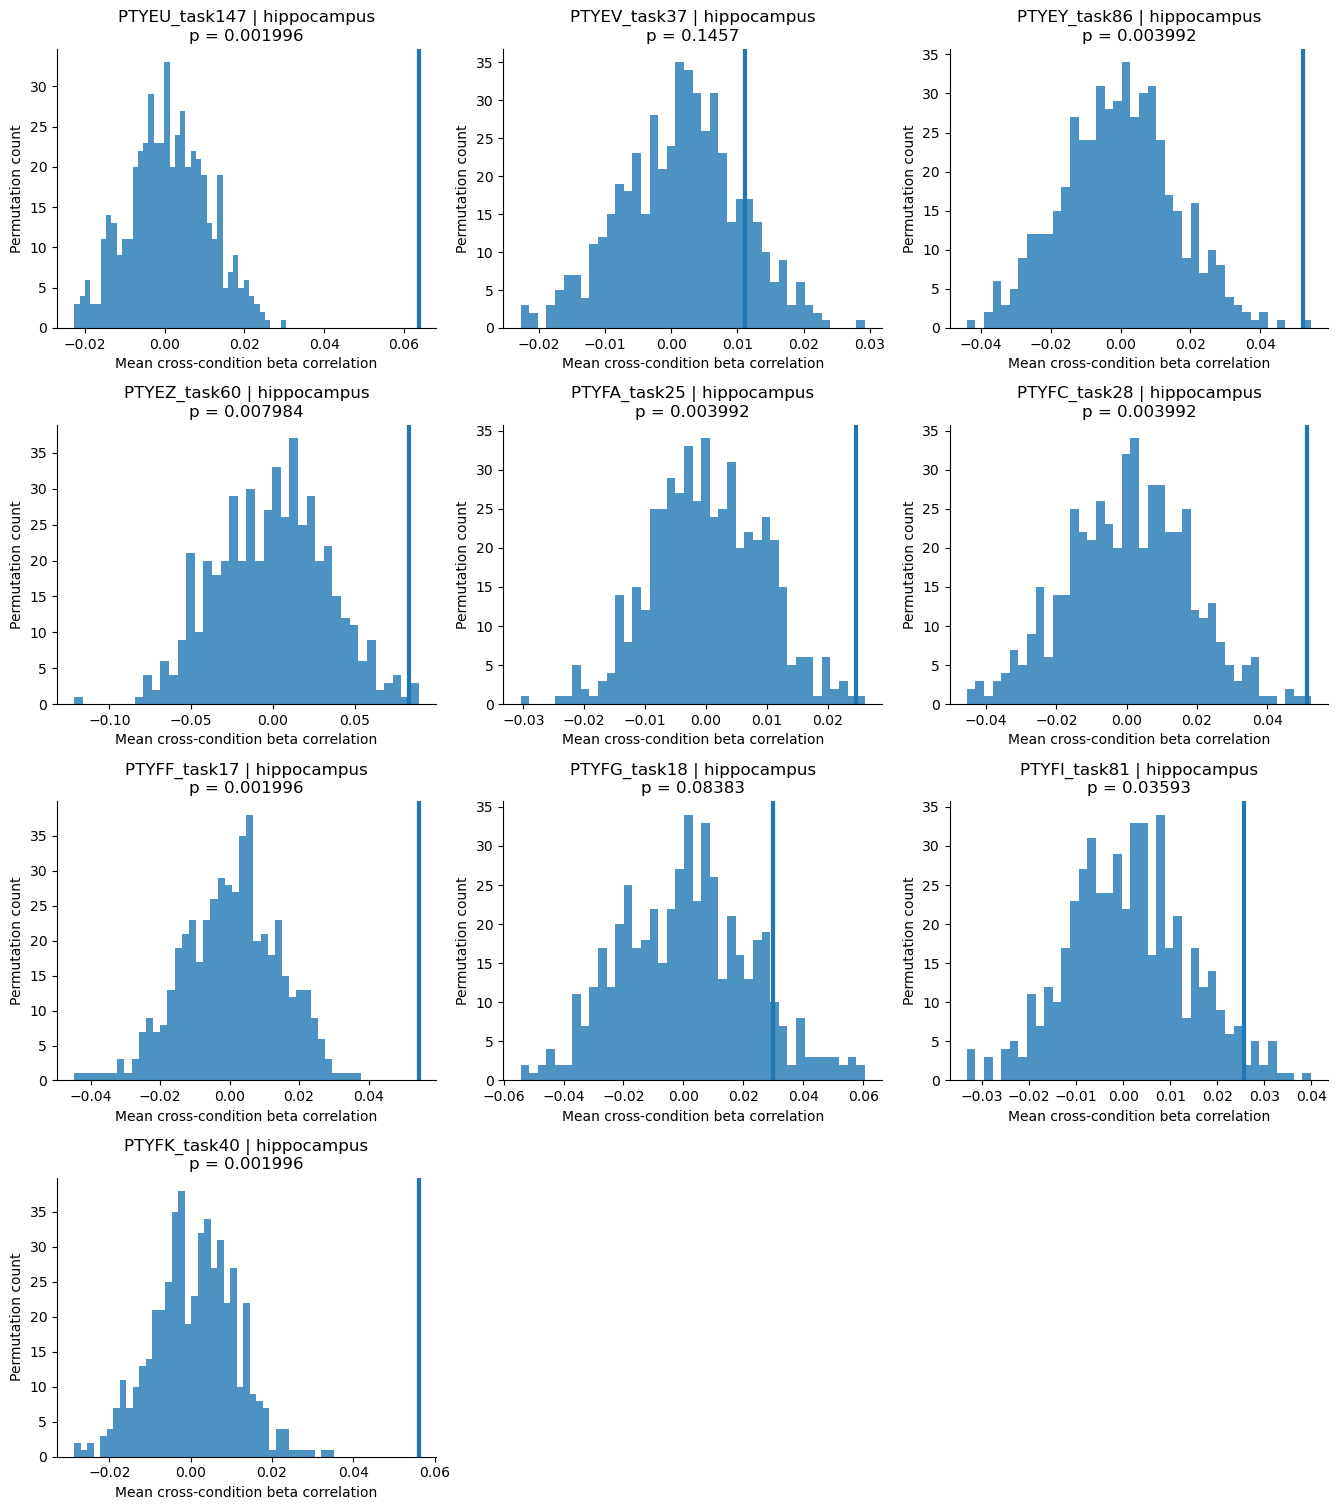

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

ROOT = "/projects/bhayden/anilu/Language_docs/BETA_WEIGHTS_ALL_PATIENTS_SECOND_PASS_REMOVED_SIG"

files = sorted(glob.glob(os.path.join(ROOT, "*", "*", "*_betas_SECOND_PASS_removedSig.npz")))
print("Found files:", len(files))

n_files = len(files)
ncols = 3
nrows = int(np.ceil(n_files / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.8*nrows))
axes = np.atleast_1d(axes).ravel()

summary_rows = []

for ax, fp in zip(axes, files):
    z = np.load(fp, allow_pickle=True)

    patient_ID = str(z["patient_ID"])
    region = str(z["region"])
    r_obs = z["r_obs"]
    r_null = z["r_null"]
    failed = z["failed"]

    valid = (~failed) & np.isfinite(r_obs)
    if valid.sum() == 0:
        ax.set_visible(False)
        continue

    T_obs = np.nanmean(r_obs[valid])
    T_null = np.nanmean(r_null[valid, :], axis=0)
    p_pop = (1 + np.sum(T_null >= T_obs)) / (len(T_null) + 1)

    summary_rows.append({
        "patient_ID": patient_ID,
        "region": region,
        "n_valid_neurons": int(valid.sum()),
        "mean_r_obs": float(T_obs),
        "null_mean": float(np.nanmean(T_null)),
        "null_sd": float(np.nanstd(T_null, ddof=1)),
        "p_pop": float(p_pop),
    })

    ax.hist(T_null, bins=40, alpha=0.8)
    ax.axvline(T_obs, linewidth=3)
    ax.set_title(f"{patient_ID} | {region}\np = {p_pop:.4g}")
    ax.set_xlabel("Mean cross-condition beta correlation")
    ax.set_ylabel("Permutation count")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for ax in axes[len(files):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()